In [ ]:
!pip install pandas numpy matplotlib seaborn pandarallel
!pip install emoji sastrawi googletrans==4.0.0-rc1
!pip install scikit-learn imbalanced-learn
!pip install tensorflow keras
!pip install transformers torch

  Preparing metadata (setup.py) ... done
  Created wheel for pandarallel: filename=pandarallel-1.6.5-py3-none-any.whl size=16674 sha256=85940c35a24ad71fe289062cc5394131a85625b496a300d60f9117d72c23b469
  Stored in directory: /root/.cache/pip/wheels/b9/c6/5a/829298789e94348b81af52ab42c19d49da007306bbcc983827
Successfully built pandarallel
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 59.7 MB/s e

In [ ]:
# ===== IMPORT LIBRARIES =====
import pandas as pd
import numpy as np
import re
import os
import emoji
import gc
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
from pandarallel import pandarallel

# NLP Libraries
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from googletrans import Translator

# Machine Learning Libraries
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score
from imblearn.over_sampling import ADASYN

# Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Embedding, Input, TimeDistributed, Attention, concatenate, GlobalAveragePooling1D, Reshape, Permute
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Transformers
from transformers import AutoTokenizer, AutoModel
import torch
pandarallel.initialize(progress_bar=True)

from google.colab import drive
drive.mount('/content/drive')

INFO: Pandarallel will run on 4 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Mounted at /content/drive


In [ ]:
oversample_dir = '/content/drive/MyDrive/Semester VIII/Tugas Akhir/Oversampled_Data/'
if not os.path.exists(oversample_dir):
    os.makedirs(oversample_dir)
    print(f"Created oversample directory: {oversample_dir}")

metrics_dir = '/content/drive/MyDrive/Semester VIII/Tugas Akhir/Metrics/'
if not os.path.exists(metrics_dir):
    os.makedirs(metrics_dir)
    print(f"Created metrics directory: {metrics_dir}")
else:
    print(f"Metrics directory already exists: {metrics_dir}")

Metrics directory already exists: /content/drive/MyDrive/Semester VIII/Tugas Akhir/Metrics/


In [ ]:
class Config:
    DRIVE_PATH = '/content/drive/MyDrive/Semester VIII/Tugas Akhir/Dataset/'
    DATASET1_PATH = 'bank_BNI_labeled.csv'
    DATASET2_PATH = 'bank_Jateng_labeled.csv'

    ASPECT_COLUMNS = [
        'ketersediaan', 'pelayanan', 'tempat', 'kenyamanan',
        'antrian', 'informasi', 'keamanan', 'pengaduan', 'aksesibilitas'
    ]

    MAX_LEN = 96
    BATCH_SIZE = 64
    EPOCHS = 15
    LEARNING_RATE = 1e-3

    LABEL_MAP = {'positif': 2, 'negatif': 0, 'Not Mentioned': 1}
    REVERSE_LABEL_MAP = {2: 'positif', 0: 'negatif', 1: 'Not Mentioned'}

In [ ]:
sampling_file_path = '/content/drive/MyDrive/Semester VIII/Tugas Akhir/Dataset/sampling.py'

try:
    %run "{sampling_file_path}"
    print(f"Successfully loaded {sampling_file_path}")
except FileNotFoundError:
    print(f"Error: File not found at {sampling_file_path}")
    print("Please check the file path and ensure Google Drive is mounted correctly.")
except Exception as e:
    print(f"An error occurred while running the file: {e}")

Successfully loaded /content/drive/MyDrive/Semester VIII/Tugas Akhir/Dataset/sampling.py


In [ ]:
class TextPreprocessor:
    def __init__(self):
        factory = StemmerFactory()
        self.stemmer = factory.create_stemmer()
        stop_factory = StopWordRemoverFactory()
        self.stopword_remover = stop_factory.create_stop_word_remover()
        #self.translator = Translator()
        self.normalization_dict = {
            'gk': 'tidak', 'ga': 'tidak', 'tdk': 'tidak',
            'dgn': 'dengan', 'utk': 'untuk', 'krn': 'karena',
            'yg': 'yang', 'sy': 'saya', 'klo': 'kalau',
            'tp': 'tapi', 'bs': 'bisa', 'blm': 'belum',
            'sdh': 'sudah', 'lg': 'lagi', 'aj': 'saja'
        }

    def normalize_text(self, text):
            """Normalisasi kata"""
            if pd.isna(text):
                return ""
            text = str(text).lower()
            words = text.split()
            normalized_words = [self.normalization_dict.get(word, word) for word in words]
            return ' '.join(normalized_words)

    def translate_mixed_text(self, text):
        """Translate bahasa campuran ke bahasa Indonesia (TETAP SERIAL)"""
        try:
            if pd.isna(text) or text == "":
                return ""
            translator = Translator()
            detected = translator.detect(text)
            if detected.lang != 'id' and detected.confidence > 0.7:
                translated = translator.translate(text, dest='id')
                return translated.text
            return text
        except Exception as e:
            print(f"Translation error for text: '{text[:50]}...' - {e}")
            return text

    def demojize_text(self, text):
        """Convert emoji ke text"""
        if pd.isna(text):
            return ""
        return emoji.demojize(text, language='id')

    def clean_text(self, text):
        """Pembersihan teks umum"""
        if pd.isna(text):
            return ""
        text = str(text)
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text)
        return text.strip()

    def stem_text(self, text):
        """Stemming menggunakan Sastrawi"""
        if pd.isna(text) or text == "":
            return ""
        return self.stemmer.stem(text)

    def preprocess_text(self, text):
        """Pipeline preprocessing lengkap (SERIAL)"""
        text = self.normalize_text(text)
        text = self.translate_mixed_text(text)
        text = self.demojize_text(text)
        text = self.clean_text(text)
        text = self.stem_text(text)
        return text

    def preprocess_text_parallel(self, series):
        """Pipeline preprocessing lengkap (PARALEL)"""
        normalization_dict = self.normalization_dict
        stemmer_instance = self.stemmer

        def normalize_text_local(text):
             if pd.isna(text):
                 return ""
             text = str(text).lower()
             words = text.split()
             normalized_words = [normalization_dict.get(word, word) for word in words]
             return ' '.join(normalized_words)

        def clean_text_local(text):
             if pd.isna(text):
                 return ""
             text = str(text)
             text = re.sub(r'[^a-zA-Z\s]', ' ', text)
             text = re.sub(r'\s+', ' ', text)
             return text.strip()

        def stem_text_local(text):
             if pd.isna(text) or text == "":
                 return ""
             return stemmer_instance.stem(text)

        def demojize_text_local(text):
             """Convert emoji ke text"""
             if pd.isna(text):
                 return ""
             return emoji.demojize(text, language='id')

        print("Starting parallel preprocessing (Normalize, Demojize, Clean, Stem)...")
        processed_series = series.parallel_apply(normalize_text_local)
        processed_series = processed_series.parallel_apply(demojize_text_local)
        processed_series = processed_series.parallel_apply(clean_text_local)
        processed_series = processed_series.parallel_apply(stem_text_local)
        print("Parallel preprocessing finished.")

        return processed_series

    def preprocess_time(self, time_str):
        """Convert time ke format dd/mm/yyyy"""
        try:
            if pd.isna(time_str):
                return None
            formats = ['%Y-%m-%d', '%d/%m/%Y', '%m/%d/%Y', '%Y-%m-%d %H:%M:%S']
            for fmt in formats:
                try:
                    dt = datetime.strptime(str(time_str), fmt)
                    return dt.strftime('%d/%m/%Y')
                except:
                    continue
            return str(time_str)
        except:
            return None

    def preprocess_rating(self, rating):
        """Extract integer dari rating"""
        try:
            if pd.isna(rating):
                return None
            numbers = re.findall(r'\d+', str(rating))
            if numbers:
                return int(numbers[0])
            return None
        except:
            return None

In [ ]:
# Modifikasi Kelas IndoBERTFeatureExtractor
class IndoBERTFeatureExtractor:
    def __init__(self, cache_dir="/content/indobert_features_cache"):
        self.tokenizer = AutoTokenizer.from_pretrained('indolem/indobert-base-uncased')
        self.model = AutoModel.from_pretrained('indolem/indobert-base-uncased')
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        self.inference_batch_size = 64
        self.cache_dir = cache_dir
        if not os.path.exists(self.cache_dir):
            os.makedirs(self.cache_dir)

    def extract_features(self, texts, max_length=64, cache_file_prefix="features", return_2d=False):

        cache_filename = f"{cache_file_prefix}_maxlen_{max_length}"
        if return_2d:
            cache_filename += "_2d"
        cache_filename += ".npy"
        cache_filepath = os.path.join(self.cache_dir, cache_filename)

        if os.path.exists(cache_filepath):
            print(f"Loading features from cache: {cache_filepath}")
            try:
                features = np.load(cache_filepath)
                if len(features) == len(texts):
                     print("Cache loaded successfully.")
                     return features
                else:
                     print("Warning: Cache mismatch (number of texts). Re-extracting features.")
            except Exception as e:
                print(f"Error loading cache file: {e}. Re-extracting features.")

        print(f"Extracting { '2D' if return_2d else '3D'} features using IndoBERT...")
        all_features = []

        if not isinstance(texts, (list, np.ndarray, pd.Series)): # Tambahkan pd.Series support jika inputnya dari DataFrame
            print("Input 'texts' should be a list, numpy array, or pandas Series of strings.")
            return np.array([])
        cleaned_texts = [str(text) if pd.notna(text) else "" for text in texts]


        for i in range(0, len(cleaned_texts), self.inference_batch_size):
            batch_texts = cleaned_texts[i : i + self.inference_batch_size]
            print(f"Processing batch {i // self.inference_batch_size + 1}/{(len(cleaned_texts) + self.inference_batch_size - 1) // self.inference_batch_size} with {len(batch_texts)} texts...")

            if not batch_texts:
                 continue

            inputs = self.tokenizer(
                batch_texts,
                max_length=max_length,
                padding='max_length',
                truncation=True,
                return_tensors='pt',
                add_special_tokens=True
            )

            inputs = {k: v.to(self.device) for k, v in inputs.items()}

            with torch.no_grad():
                try:
                    outputs = self.model(**inputs)
                    if return_2d:

                        last_hidden_state = outputs.last_hidden_state
                        batch_features = torch.mean(last_hidden_state, dim=1).cpu().numpy()
                    else:
                        batch_features = outputs.last_hidden_state.cpu().numpy()


                    all_features.append(batch_features)
                except RuntimeError as e:
                    if "out of memory" in str(e):
                        print(f"CUDA Out of Memory error when processing batch starting at index {i}. Try reducing 'self.inference_batch_size' or 'max_length'.")

                        raise
                    else:
                        print(f"An error occurred during feature extraction for batch starting at index {i}: {e}")
                        raise
                except Exception as e:
                     print(f"An unexpected error occurred during feature extraction for batch starting at index {i}: {e}")
                     raise


        if all_features:
            features = np.concatenate(all_features, axis=0)
            print(f"Feature extraction complete. Shape: {features.shape}")
            try:
                np.save(cache_filepath, features)
                print(f"Features saved to cache: {cache_filepath}")
            except Exception as e:
                print(f"Warning: Could not save features to cache: {e}")

        else:
            features = np.array([])
            print("No features extracted.")

        return features

    def clear_cache(self):
        import shutil
        cache_dir = "/content/indobert_features_cache"
        if os.path.exists(self.cache_dir):
            print(f"Clearing cache directory: {self.cache_dir}")
            try:
                shutil.rmtree(self.cache_dir)
                print("Cache cleared.")
            except Exception as e:
                print(f"Error clearing cache: {e}")
        else:
            print("Cache directory does not exist.")

In [ ]:
# ===== ASPECT SENTIMENT CLASSIFIER =====
class AspectSentimentClassifier:
    def __init__(self, config, fold=5):
        self.config = config
        self.models = {}
        self.label_encoders = {}
        self.fold = fold
        self.sampling = Sampling(fold=self.fold)
        self.aspect_fold_metrics = {aspect: [] for aspect in config.ASPECT_COLUMNS}

    def create_proper_bilstm_model(self, input_shape, num_classes):
        model = Sequential([
            Input(shape=input_shape),
            #Bidirectional(LSTM(128, return_sequences=True)),
            #Dropout(0.4),
            Bidirectional(LSTM(32, return_sequences=False, recurrent_dropout=0.1)),
            Dropout(0.4),
            Dense(32, activation='relu'),
            Dropout(0.3),
            Dense(32, activation='relu'),
            Dropout(0.3),
            Dense(num_classes, activation='softmax')
        ])

        optimizer = tf.keras.optimizers.AdamW(learning_rate=self.config.LEARNING_RATE)

        model.compile(
            optimizer=optimizer,
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        return model

    def generate_and_save_oversampled_data(self, X_train_3D, y_train_aspects, aspect_analysis_df, oversample_output_dir):
        print("\nChecking for existing oversampled data...")
        aspects = self.config.ASPECT_COLUMNS

        if X_train_3D is None or X_train_3D.ndim != 3 or X_train_3D.shape[0] == 0:
            print("Error: Original X_train_3D is not valid. Cannot generate oversampled data.")
            return

        expected_features_shape = (X_train_3D.shape[1], X_train_3D.shape[2])
        expected_y_dtype = np.int64

        all_files_exist = True
        expected_files = []

        for aspect in aspects:
            valid_y = y_train_aspects[aspect].dropna()
            if len(valid_y) > 0:
                try:
                    estimated_folds = self.fold
                    for fold in range(estimated_folds):

                        expected_files.append(os.path.join(oversample_output_dir, f'{aspect}_fold_{fold}_X.npy'))
                        expected_files.append(os.path.join(oversample_output_dir, f'{aspect}_fold_{fold}_y.npy'))

                except Exception as e:
                    print(f"Warning: Could not estimate folds for aspect {aspect} to check files: {e}")
                    all_files_exist = False
                    pass


        if not expected_files:
             print("  No valid aspects found with data or no folds estimated, no files to check or generate.")
             return

        print(f"  Checking for {len(expected_files)} expected oversampled files...")
        for file_path in expected_files:
            if not os.path.exists(file_path):
                print(f"  Missing file: {file_path}")
                all_files_exist = False
            else:
                try:
                    with open(file_path, 'rb') as f:
                        magic = np.lib.format.read_magic(f)
                        version = magic[1]
                        if version not in (1, 2, 3):
                             print(f"  Unknown .npy file version for {file_path}.")
                             all_files_exist = False
                             continue

                        header_dict = np.lib.format._read_array_header(f, version)
                        shape = header_dict['shape']
                        dtype = header_dict['descr']

                    if '_X.npy' in file_path:
                        if len(shape) != 3 or shape[1:] != expected_features_shape:
                             print(f"  Shape mismatch for file: {file_path} (Expected suffix: {expected_features_shape}, Found: {shape})")
                             all_files_exist = False
                    elif '_y.npy' in file_path:
                         if len(shape) != 1 or not np.issubdtype(np.dtype(dtype), np.integer):
                              print(f"  Shape or Dtype mismatch for file: {file_path} (Expected: (ANY,), Dtype: Integer, Found: {shape}, Dtype: {dtype})")
                              all_files_exist = False

                except Exception as e:
                    print(f"  Error checking file {file_path}: {e}. File might be corrupt.")
                    all_files_exist = False


        if all_files_exist:
            print("  All expected oversampled fold data files found and appear consistent. Skipping data generation.")
            return
        else:
            print("  One or more oversampled fold data files not found or are inconsistent. Proceeding with data generation.")

        print("\nGenerating and saving oversampled data per fold...")

        y_encoded_aspects = {}
        valid_original_index_map = {}

        for aspect in aspects:
            le = LabelEncoder()
            valid_y = y_train_aspects[aspect].dropna()
            if len(valid_y) > 0:
                valid_original_index = y_train_aspects[aspect].dropna().index
                y_encoded_aspects[aspect] = le.fit_transform(valid_y.values)

                if aspect not in self.label_encoders or self.label_encoders[aspect] is None:
                     self.label_encoders[aspect] = le
                valid_original_index_map[aspect] = valid_original_index
            else:
                print(f"Warning: No valid labels found for aspect '{aspect}'. Skipping data generation.")

                y_encoded_aspects[aspect] = np.array([])
                self.label_encoders[aspect] = None
                valid_original_index_map[aspect] = pd.Index([])


        os.makedirs(oversample_output_dir, exist_ok=True)

        for aspect in aspects:
            if self.label_encoders.get(aspect) is None or len(y_encoded_aspects[aspect]) == 0:
                print(f"\\nSkipping oversample data generation for aspect '{aspect}' due to no valid data.")
                continue

            print(f"\\nGenerating data for aspect: {aspect}")

            y_aspect_valid_encoded = y_encoded_aspects[aspect]
            aspect_valid_original_indices_df = valid_original_index_map[aspect]
            aspect_valid_positional_indices = aspect_analysis_df.index.get_indexer(aspect_valid_original_indices_df)
            X_aspect_valid_3D = X_train_3D[aspect_valid_positional_indices]

            acv_folds = list(self.sampling.ACV(y_aspect_valid_encoded))
            if not acv_folds:
                print(f"  Peringatan: ACV tidak menghasilkan fold untuk aspek '{aspect}'.")
                continue

            for fold, (train_local_indices, test_local_indices) in enumerate(acv_folds):
                print(f"    Processing Fold {fold+1}/{len(acv_folds)}")

                X_train_fold_3D = X_aspect_valid_3D[train_local_indices]
                y_train_fold = y_aspect_valid_encoded[train_local_indices]
                train_counts_before = Counter(y_train_fold)

                # --- PERBAIKAN LOGIKA ADASYN ---

                # 1. Pengecekan awal: Lewati jika data sudah seimbang atau hanya punya 1 kelas
                if len(train_counts_before) <= 1:
                    print(f"      Fold {fold+1} - Skipping ADASYN: Hanya ada satu kelas.")
                    X_train_fold_resampled_3D = X_train_fold_3D
                    y_train_fold_resampled = y_train_fold
                else:
                    # Cari kelas minoritas dan jumlah sampelnya
                    majority_class_count = max(train_counts_before.values())
                    minority_classes = {cls: count for cls, count in train_counts_before.items() if count < majority_class_count}

                    # Lewati jika tidak ada kelas minoritas (data sudah seimbang)
                    if not minority_classes:
                        print(f"      Fold {fold+1} - Skipping ADASYN: Data sudah seimbang.")
                        X_train_fold_resampled_3D = X_train_fold_3D
                        y_train_fold_resampled = y_train_fold
                    else:
                        # 2. Tentukan n_neighbors secara dinamis
                        min_minority_count = min(minority_classes.values())
                        # n_neighbors harus lebih kecil dari jumlah sampel di kelas minoritas terkecil
                        n_neighbors = max(1, min_minority_count - 1)

                        # 3. Strategi sampling yang lebih sederhana: samakan semua kelas minoritas dengan mayoritas
                        sampling_strategy_fold = {cls: majority_class_count for cls in minority_classes.keys()}

                        print(f"      Fold {fold+1} - Applying ADASYN with strategy: {sampling_strategy_fold} and n_neighbors: {n_neighbors}")

                        try:
                            adasyn_fold = ADASYN(sampling_strategy=sampling_strategy_fold, n_neighbors=n_neighbors, random_state=42)
                            X_train_fold_2D = X_train_fold_3D.reshape(X_train_fold_3D.shape[0], -1)
                            X_train_fold_resampled_2D, y_train_fold_resampled = adasyn_fold.fit_resample(X_train_fold_2D, y_train_fold)
                            X_train_fold_resampled_3D = X_train_fold_resampled_2D.reshape(-1, X_train_fold_3D.shape[1], X_train_fold_3D.shape[2])
                            print(f"      Fold {fold+1} - Resampling successful. New distribution: {Counter(y_train_fold_resampled)}")
                        except Exception as e:
                            print(f"      Fold {fold+1} - ADASYN failed: {e}, using original fold data.")
                            X_train_fold_resampled_3D = X_train_fold_3D
                            y_train_fold_resampled = y_train_fold

                # Simpan hasil (baik yang sudah di-resample maupun yang asli jika gagal)
                fold_X_path = os.path.join(oversample_output_dir, f'{aspect}_fold_{fold}_X.npy')
                fold_y_path = os.path.join(oversample_output_dir, f'{aspect}_fold_{fold}_y.npy')

                try:
                    np.save(fold_X_path, X_train_fold_resampled_3D)
                    np.save(fold_y_path, y_train_fold_resampled)
                    print(f"      Saved Fold {fold+1} data.")
                except Exception as e:
                    print(f"      Error saving Fold {fold+1} data: {e}")

                del X_train_fold_resampled_3D, y_train_fold_resampled
                gc.collect()

        print("\\nOversampled data generation and saving complete.")


    def train_aspect_models(self, X_train_3D, y_train_aspects, aspect_analysis_df, oversample_output_dir):
        print("\nTraining aspect sentiment models using saved oversampled data...")

        aspects = self.config.ASPECT_COLUMNS
        self.models = {}
        self.aspect_fold_metrics = {aspect: [] for aspect in aspects}

        if X_train_3D is not None and X_train_3D.ndim == 3:
            input_shape = (X_train_3D.shape[1], X_train_3D.shape[2])
        else:
            print("Error: Original X_train_3D is not in the expected 3D format. Cannot train aspect models.")
            for aspect in aspects:
                self.models[aspect] = None
                self.aspect_fold_metrics[aspect] = []
            return self.models, {}, self.label_encoders

        y_encoded_aspects = {}
        valid_original_index_map = {}
        all_possible_labels = ['positif', 'negatif', 'Not Mentioned']  # <<< PASTIKAN LABEL TETAP

        for aspect in aspects:
            le = LabelEncoder()
            le.fit(sorted(all_possible_labels))  # <<< MODIFIKASI: urutan deterministik
            valid_y = y_train_aspects[aspect].dropna()

            if len(valid_y) > 0:
                valid_original_index = valid_y.index
                try:
                    y_encoded_aspects[aspect] = le.transform(valid_y.values)
                except ValueError as e:
                    print(f"Error transforming labels for aspect '{aspect}': {e}.")
                    y_encoded_aspects[aspect] = np.array([])
                    valid_original_index = pd.Index([])

                self.label_encoders[aspect] = le
                valid_original_index_map[aspect] = valid_original_index
            else:
                print(f"Warning: No valid labels found for aspect '{aspect}'. Skipping training.")
                y_encoded_aspects[aspect] = np.array([])
                self.label_encoders[aspect] = le
                valid_original_index_map[aspect] = pd.Index([])

        all_aspect_avg_metrics = {}

        for aspect in aspects:
            if self.label_encoders.get(aspect) is None or len(self.label_encoders[aspect].classes_) < len(all_possible_labels):
                print(f"\nSkipping aspect '{aspect}': LabelEncoder not properly initialized or missing classes.")
                all_aspect_avg_metrics[aspect] = "LabelEncoder issue"
                self.models[aspect] = None
                continue

            if len(y_encoded_aspects[aspect]) == 0:
                print(f"\nSkipping aspect '{aspect}' due to no valid data.")
                all_aspect_avg_metrics[aspect] = "No valid data for training"
                self.models[aspect] = None
                continue

            print(f"\nTraining model for aspect: {aspect}")
            y_aspect_valid_encoded = y_encoded_aspects[aspect]
            num_classes = len(self.label_encoders[aspect].classes_)  # <<< GUNAKAN ENCODER
            class_names = self.label_encoders[aspect].classes_

            print(f"  Evaluating using ACV folds...")
            acv_folds = list(self.sampling.ACV(y_aspect_valid_encoded))
            actual_num_folds = len(acv_folds)
            print(f"  ACV generated {actual_num_folds} folds for aspect '{aspect}'.")

            if actual_num_folds == 0:
                print(f"  Warning: No folds generated. Skipping {aspect}.")
                all_aspect_avg_metrics[aspect] = "No CV folds generated"
                self.models[aspect] = None
                continue

            aspect_valid_original_indices_df = valid_original_index_map[aspect]
            aspect_valid_positional_indices = aspect_analysis_df.index.get_indexer(aspect_valid_original_indices_df)
            X_aspect_valid_3D_original_subset = X_train_3D[aspect_valid_positional_indices]

            for fold, (train_local_indices, test_local_indices) in enumerate(acv_folds):
                print(f"    Fold {fold+1}/{actual_num_folds}")
                fold_X_path = os.path.join(oversample_output_dir, f'{aspect}_fold_{fold}_X.npy')
                fold_y_path = os.path.join(oversample_output_dir, f'{aspect}_fold_{fold}_y.npy')

                try:
                    if os.path.exists(fold_X_path) and os.path.exists(fold_y_path):
                        X_train_fold_resampled_3D = np.load(fold_X_path)
                        y_train_fold_resampled = np.load(fold_y_path)

                        # <<< MODIFIKASI: Validasi label hasil load >>>
                        unique_classes = np.unique(y_train_fold_resampled)
                        if not np.all(np.isin(unique_classes, np.arange(num_classes))):
                            print(f"      Warning: Loaded labels for aspect {aspect} contain unexpected classes: {unique_classes}. Expected: {np.arange(num_classes)}")

                        y_train_fold_categorical = to_categorical(y_train_fold_resampled, num_classes=num_classes)
                        X_test_fold_3D = X_aspect_valid_3D_original_subset[test_local_indices]
                        y_test_fold = y_aspect_valid_encoded[test_local_indices]
                        y_test_fold_categorical = to_categorical(y_test_fold, num_classes=num_classes)

                        model = self.create_proper_bilstm_model(input_shape, num_classes)
                        callbacks = [EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True), ReduceLROnPlateau(patience=4, factor=0.5, monitor='val_loss')]

                        history = model.fit(
                            X_train_fold_resampled_3D, y_train_fold_categorical,
                            epochs=self.config.EPOCHS,
                            batch_size=self.config.BATCH_SIZE,
                            validation_data=(X_test_fold_3D, y_test_fold_categorical),
                            callbacks=callbacks,
                            verbose=0
                        )

                        y_pred_fold = np.argmax(model.predict(X_test_fold_3D, verbose=0), axis=1)
                        y_test_fold_int = np.array(y_test_fold).astype(int)

                        f1 = f1_score(y_test_fold_int, y_pred_fold, labels=np.arange(num_classes), average='weighted', zero_division=0)
                        precision = precision_score(y_test_fold_int, y_pred_fold, labels=np.arange(num_classes), average='weighted', zero_division=0)
                        recall = recall_score(y_test_fold_int, y_pred_fold, labels=np.arange(num_classes), average='weighted', zero_division=0)
                        accuracy = np.mean(y_test_fold_int == y_pred_fold)

                        print(f"    Fold {fold+1} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

                        self.aspect_fold_metrics[aspect].append({
                            'fold': fold + 1,
                            'aspect': aspect,
                            'accuracy': accuracy,
                            'f1_score': f1,
                            'precision': precision,
                            'recall': recall
                        })

                        del model
                        tf.keras.backend.clear_session()
                        gc.collect()

                except Exception as e:
                    print(f"      Error during fold {fold+1}: {e}")

            # Rata-rata
            avg_metrics = {}
            if len(self.aspect_fold_metrics[aspect]) > 0:
                for metric in ['accuracy', 'f1_score', 'precision', 'recall']:
                    avg_metrics[metric] = np.mean([m[metric] for m in self.aspect_fold_metrics[aspect]])
                print(f"\nAverage CV Metrics for {aspect}: {avg_metrics}")
                all_aspect_avg_metrics[aspect] = avg_metrics
            else:
                all_aspect_avg_metrics[aspect] = "No CV metrics recorded"

            # <<< MODIFIKASI FINAL MODEL >>>
            final_fold = actual_num_folds - 1
            full_X_path = os.path.join(oversample_output_dir, f'{aspect}_fold_{final_fold}_X.npy')
            full_y_path = os.path.join(oversample_output_dir, f'{aspect}_fold_{final_fold}_y.npy')

            if os.path.exists(full_X_path) and os.path.exists(full_y_path):
                X_final = np.load(full_X_path)
                y_final = np.load(full_y_path)

                if not np.all(np.isin(np.unique(y_final), np.arange(num_classes))):
                    print(f"  Warning: Final y contains invalid labels for {aspect}. Skipping.")
                    self.models[aspect] = None
                    continue

                y_final_cat = to_categorical(y_final, num_classes=num_classes)
                final_model = self.create_proper_bilstm_model(input_shape, num_classes)
                try:
                    final_model.fit(X_final, y_final_cat,
                                    epochs=self.config.EPOCHS,
                                    batch_size=self.config.BATCH_SIZE,
                                    callbacks=[EarlyStopping(patience=5, monitor='loss', restore_best_weights=True)],
                                    verbose=1)
                    self.models[aspect] = final_model
                    print(f"  Final model for {aspect} trained.")
                except Exception as e:
                    print(f"  Error during final training for {aspect}: {e}")
                    self.models[aspect] = None
            else:
                print(f"  Skipping final training for {aspect}, fold data not found.")
                self.models[aspect] = None

        print("\nAspect sentiment model training complete.")
        return self.models, all_aspect_avg_metrics, self.label_encoders


    def predict_aspects(self, X_3D):
        """Prediksi semua aspek menggunakan model yang sudah dilatih dan simpan hasilnya"""
        print("\nPredicting aspects...")
        predictions_df = pd.DataFrame()

        if X_3D is None or X_3D.ndim != 3:
            print("Error: Input X for prediction is not in the expected 3D format.")
            for aspect in self.config.ASPECT_COLUMNS:
                predictions_df[aspect] = ['Error'] * (X_3D.shape[0] if X_3D is not None else 0)
            return predictions_df

        for aspect in self.config.ASPECT_COLUMNS:
            if aspect in self.models and self.models[aspect] is not None and self.label_encoders.get(aspect) is not None:
                try:
                    pred_probs = self.models[aspect].predict(X_3D, verbose=0)
                    pred_classes = np.argmax(pred_probs, axis=1)  # indeks kelas: 0, 1, 2

                    encoder_classes = self.label_encoders[aspect].classes_
                    num_classes = len(encoder_classes)

                    if pred_probs.shape[1] != num_classes:
                        print(f"Warning: Mismatch between predicted class count ({pred_probs.shape[1]}) and encoder classes ({num_classes}) for aspect '{aspect}'. Assigning 'Not Mentioned'.")
                        predictions_df[aspect] = ['Not Mentioned'] * X_3D.shape[0]
                    else:
                        try:
                            # Langsung akses kelas berdasarkan indeks prediksi
                            pred_labels = encoder_classes[pred_classes]
                            predictions_df[aspect] = pred_labels
                        except IndexError as e:
                            print(f"Warning: Predicted indices out of bounds for aspect {aspect}: {e}. Assigning 'Not Mentioned'.")
                            predictions_df[aspect] = ['Not Mentioned'] * X_3D.shape[0]

                except Exception as e:
                    print(f"Error during prediction for aspect {aspect}: {e}. Assigning 'Not Mentioned'.")
                    predictions_df[aspect] = ['Not Mentioned'] * X_3D.shape[0]
            else:
                print(f"Warning: Model or LabelEncoder not found or is None for aspect {aspect}. Assigning 'Not Mentioned'.")
                predictions_df[aspect] = ['Not Mentioned'] * X_3D.shape[0]

        return predictions_df


    def get_fold_metrics(self):

        return self.aspect_fold_metrics

    def clear_cache(self):
        """Clears the feature cache directory."""
        import shutil
        cache_dir = "/content/indobert_features_cache"
        print(f"Clearing cache directory: {cache_dir}")

In [ ]:
class RatingPredictor:
    def __init__(self, config, fold=5):
        self.config = config
        self.model = None
        self.label_encoder = LabelEncoder()
        self.fold = fold
        self.sampling = Sampling(fold=self.fold)
        self.rating_fold_metrics = []

    def sentiment_to_numeric(self, sentiment):
        """Convert a single sentiment label string to a numeric feature vector."""
        if pd.isna(sentiment):
             return [0, 0, 1] # Not Mentioned
        elif sentiment == 'positif':
            return [1, 0, 0] # Positif
        elif sentiment == 'negatif':
            return [0, 1, 0]
        else:
            return [0, 0, 1] # Default ke Not Mentioned

    def create_rating_model(self, bert_3d_input_shape, sentiment_input_shape, num_rating_classes):
        bert_3d_input = Input(shape=bert_3d_input_shape, name='bert_3d_input')

        lstm_out = Bidirectional(LSTM(64, return_sequences=True, recurrent_dropout=0.1))(bert_3d_input)
        lstm_out = Dropout(0.4)(lstm_out)
        lstm_out = Bidirectional(LSTM(64, return_sequences=False, recurrent_dropout=0.1))(lstm_out)
        lstm_out = Dropout(0.3)(lstm_out)

        sentiment_input = Input(shape=sentiment_input_shape, name='sentiment_input')
        sentiment_dense = Dense(32, activation='relu')(sentiment_input)
        sentiment_dropout = Dropout(0.3)(sentiment_dense)

        combined = concatenate([lstm_out, sentiment_dropout])
        combined_dense = Dense(16, activation='relu')(combined)
        combined_dropout = Dropout(0.3)(combined_dense)
        output = Dense(num_rating_classes, activation='softmax', name='rating_output')(combined_dropout)

        model = Model(inputs=[bert_3d_input, sentiment_input], outputs=output)
        optimizer = tf.keras.optimizers.AdamW(learning_rate=self.config.LEARNING_RATE)
        model.compile(
            optimizer=optimizer,
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

    def prepare_features_and_labels(self, aspect_predictions_df, original_ratings_series, bert_3d_features, original_index_map):
        print("\\nPreparing features and labels for two-input rating classification model...")

        if aspect_predictions_df is None or aspect_predictions_df.empty:
            print("Error: Aspect predictions DataFrame is empty or None. Cannot prepare rating data.")
            return None, None, None, None, None, None

        if original_ratings_series is None or original_ratings_series.empty:
            print("Warning: Original ratings Series is empty or None. Cannot prepare rating labels.")
            y = pd.Series(dtype=int)
        else:
            y = original_ratings_series.dropna()
            y = y[pd.to_numeric(y, errors='coerce').notna()].astype(int)
            y = y[(y >= 1) & (y <= 5)]

        valid_rating_indices = y.index
        if len(valid_rating_indices) == 0:
             print("No valid ratings found after filtering. Cannot prepare rating data.")
             return None, None, None, None, None, None

        valid_positional_indices = original_index_map.get_indexer(valid_rating_indices)
        valid_positional_indices = valid_positional_indices[valid_positional_indices != -1]

        if len(valid_positional_indices) != len(valid_rating_indices):
            print("Warning: Mismatch in number of valid rating indices and their positional indices in original data. This might indicate issues.")

        X_bert_subset_3D = bert_3d_features[valid_positional_indices]
        X_sentiment_subset_df = aspect_predictions_df.loc[valid_rating_indices].copy()
        y_subset = y

        print(f"  Subset shapes for Rating Preparation:")
        print(f"    X_bert_subset_3D.shape: {X_bert_subset_3D.shape}")
        print(f"    X_sentiment_subset_df.shape: {X_sentiment_subset_df.shape}")
        print(f"    y_subset.shape: {y_subset.shape}")

        if X_bert_subset_3D.shape[0] != X_sentiment_subset_df.shape[0] or X_bert_subset_3D.shape[0] != y_subset.shape[0]:
             print("Error: Shape mismatch between BERT features, sentiment features, and ratings after subsetting. Cannot proceed.")
             return None, None, None, None, None, None

        sentiment_map = {'positif': [1, 0, 0], 'negatif': [0, 1, 0], 'Not Mentioned': [0, 0, 1]}
        num_sentiment_classes = 3

        def flatten_sentiments_subset(row, aspect_list, sentiment_mapping):
            flat_vector = []
            for aspect in aspect_list:
                 sentiment = row.get(f'{aspect}_predicted', 'Not Mentioned')
                 if pd.isna(sentiment) or sentiment == 'Error' or sentiment == 'N/A':
                      sentiment = 'Not Mentioned'
                 flat_vector.extend(sentiment_mapping.get(sentiment, [0, 0, 1]))
            return flat_vector

        print("  Applying flatten_sentiments for rating data...")
        if 'parallel_apply' in dir(X_sentiment_subset_df):
            try:
                X_sentiment_subset_list = X_sentiment_subset_df.parallel_apply(
                    flatten_sentiments_subset,
                    axis=1,
                    aspect_list=self.config.ASPECT_COLUMNS,
                    sentiment_mapping=sentiment_map
                ).tolist()
                print("  Parallel sentiment feature flattening complete.")
            except Exception as e:
                print(f"  Parallel apply failed: {e}. Falling back to standard apply.")
                X_sentiment_subset_list = X_sentiment_subset_df.apply(
                    flatten_sentiments_subset,
                    axis=1,
                    aspect_list=self.config.ASPECT_COLUMNS,
                    sentiment_mapping=sentiment_map
                ).tolist()
        else:
            print("  Pandarallel not available for sentiment feature flattening. Using standard apply.")
            X_sentiment_subset_list = X_sentiment_subset_df.apply(
                flatten_sentiments_subset,
                axis=1,
                aspect_list=self.config.ASPECT_COLUMNS,
                sentiment_mapping=sentiment_map
            ).tolist()

        X_sentiment_subset = np.array(X_sentiment_subset_list)
        expected_sentiment_shape = len(self.config.ASPECT_COLUMNS) * num_sentiment_classes
        if X_sentiment_subset.shape[1] != expected_sentiment_shape:
             print(f"Error: Dimension mismatch in flattened sentiment features for subset ({X_sentiment_subset.shape[1]} vs {expected_sentiment_shape}). Cannot train rating model.")
             return None, None, None, None, None, None

        all_possible_ratings = [1, 2, 3, 4, 5]
        self.label_encoder.fit(sorted(all_possible_ratings))
        num_rating_classes = len(self.label_encoder.classes_)
        y_encoded_subset = self.label_encoder.transform(y_subset)

        # --- PERBAIKAN: Nama variabel di return diubah agar konsisten, meskipun isinya sama
        return X_bert_subset_3D, X_sentiment_subset, y_encoded_subset, valid_rating_indices, self.label_encoder, num_rating_classes

    # --- PERBAIKAN: Nama argumen diubah menjadi y_rating_encoded_train untuk kejelasan
    def train_rating_model(self, X_bert_3d_subset, X_sentiments_subset, y_rating_encoded_train, subset_indices, rating_classes):
        print("\\n  Training Rating Prediction Model using combined features...")

        if X_bert_3d_subset is None or X_bert_3d_subset.size == 0 or X_sentiments_subset is None or X_sentiments_subset.size == 0 or y_rating_encoded_train is None or y_rating_encoded_train.size == 0:
            print("  Error: Input data for rating model training is empty or None.")
            return None, "Input data empty"

        if y_rating_encoded_train.ndim != 1:
            print(f"  Error: y_rating_encoded_train has incorrect dimensions ({y_rating_encoded_train.ndim}). Expected 1D.")
            return None, "y_rating_encoded_train dimension error"

        # --- PERBAIKAN: Konversi ke int jika perlu
        if not np.issubdtype(y_rating_encoded_train.dtype, np.integer):
            print(f"  Warning: y_rating_encoded_train is not integer type ({y_rating_encoded_train.dtype}). Converting to int.")
            try:
                 y_rating_encoded_train = y_rating_encoded_train.astype(int)
            except Exception as e:
                 print(f"  Error converting y_rating_encoded_train to int: {e}")
                 return None, "y_rating_encoded_train dtype conversion error"

        unique_classes_in_subset = np.unique(y_rating_encoded_train)
        num_classes_in_subset = len(unique_classes_in_subset)
        num_rating_classes = len(self.label_encoder.classes_)

        if num_rating_classes < 2:
             print(f"  Error: Number of rating classes is less than 2 ({num_rating_classes}). Cannot train a classifier.")
             return None, "Insufficient rating classes"

        print(f"  Number of rating classes for model: {num_rating_classes}")
        print(f"  Unique classes in training subset: {unique_classes_in_subset}")

        self.rating_fold_metrics = []
        can_stratify = True
        if num_classes_in_subset > 1:
            for class_label in unique_classes_in_subset:
                count = np.sum(y_rating_encoded_train == class_label)
                if count < self.fold:
                    print(f"  Warning: Class {class_label} (encoded) has only {count} samples, less than {self.fold} folds. StratifiedKFold might fail.")
                    can_stratify = False
        else:
            can_stratify = False
            print("  Warning: Only one unique class in training subset. Cannot use StratifiedKFold.")


        if can_stratify:
            try:
                print(f"  Attempting StratifiedKFold with {self.fold} splits...")
                skf = StratifiedKFold(n_splits=self.fold, shuffle=True, random_state=42)
                folds = list(skf.split(X_bert_3d_subset, y_rating_encoded_train))
                print(f"  StratifiedKFold successful. Generated {len(folds)} folds.")
            except ValueError as e:
                 print(f"  Error creating StratifiedKFold splits: {e}. Falling back to KFold.")
                 kfold = KFold(n_splits=self.fold, shuffle=True, random_state=42)
                 folds = list(kfold.split(X_bert_3d_subset, y_rating_encoded_train))
                 print(f"  Using KFold splits: {len(folds)} folds generated.")
        else:
            print(f"  Using KFold with {self.fold} splits as StratifiedKFold is not applicable or failed.")
            kfold = KFold(n_splits=self.fold, shuffle=True, random_state=42)
            folds = list(kfold.split(X_bert_3d_subset, y_rating_encoded_train))
            print(f"  KFold splits generated: {len(folds)} folds.")

        actual_num_folds = len(folds)
        if actual_num_folds == 0:
            print("  Error: No folds generated. Cannot train rating model.")
            return None, "No CV folds generated"

        print(f"  Training and evaluating over {actual_num_folds} folds with ADASYN...")
        for fold, (train_local_indices, test_local_indices) in enumerate(folds):
            print(f"\\n    Rating Fold {fold+1}/{actual_num_folds}")

            X_train_fold_bert = X_bert_3d_subset[train_local_indices]
            X_train_fold_sentiment = X_sentiments_subset[train_local_indices]
            y_train_fold_encoded = y_rating_encoded_train[train_local_indices]

            X_test_fold_bert = X_bert_3d_subset[test_local_indices]
            X_test_fold_sentiment = X_sentiments_subset[test_local_indices]
            y_test_fold_encoded = y_rating_encoded_train[test_local_indices]

            print(f"      Fold {fold+1} - Original training shape: {X_train_fold_bert.shape}, {X_train_fold_sentiment.shape}, {y_train_fold_encoded.shape}")
            train_counts_before = Counter(y_train_fold_encoded)
            print(f"      Fold {fold+1} - Training class distribution before ADASYN: {train_counts_before}")

            X_train_fold_combined = np.concatenate([X_train_fold_bert.reshape(X_train_fold_bert.shape[0], -1), X_train_fold_sentiment], axis=1)

            majority_class_count = 0
            majority_class_label = -1
            if train_counts_before:
                majority_class_label = max(train_counts_before, key=train_counts_before.get)
                majority_class_count = train_counts_before[majority_class_label]

            sampling_strategy_fold = {}
            if majority_class_count > 0:
                proportion_target = 0.2
                min_target_minority_count = 5
                for class_label_int in np.arange(num_rating_classes):
                    current_count = train_counts_before.get(class_label_int, 0)
                    if current_count > 0:
                        if class_label_int != majority_class_label:
                             sampling_strategy_fold[class_label_int] = max(current_count, min_target_minority_count, int(majority_class_count * proportion_target))
                        else:
                             sampling_strategy_fold[class_label_int] = current_count

            classes_to_oversample = [cls for cls, count in sampling_strategy_fold.items() if count > train_counts_before.get(cls, 0)]
            print(f"      Fold {fold+1} - ADASYN strategy: {sampling_strategy_fold}")
            print(f"      Fold {fold+1} - Classes to oversample: {classes_to_oversample}")

            X_train_fold_resampled_bert = X_train_fold_bert
            X_train_fold_resampled_sentiment = X_train_fold_sentiment
            y_train_fold_resampled = np.array(y_train_fold_encoded).astype(int)

            if classes_to_oversample and len(unique_classes_in_subset) > 1:
                try:
                    print(f"      Fold {fold+1} - Applying ADASYN...")
                    adasyn_fold = ADASYN(sampling_strategy=sampling_strategy_fold, random_state=42, n_neighbors=max(1, min(train_counts_before.values()) - 1) if min(train_counts_before.values()) > 1 else 1)
                    X_train_fold_resampled_combined, y_train_fold_resampled = adasyn_fold.fit_resample(
                        X_train_fold_combined, y_train_fold_encoded
                    )
                    print(f"      Fold {fold+1} - Training class distribution after ADASYN: {Counter(y_train_fold_resampled)}")
                    print(f"      Fold {fold+1} - Resampled combined shape: {X_train_fold_resampled_combined.shape}")

                    bert_feature_size = X_bert_3d_subset.shape[1] * X_bert_3d_subset.shape[2]
                    X_train_fold_resampled_bert_flat = X_train_fold_resampled_combined[:, :bert_feature_size]
                    X_train_fold_resampled_sentiment = X_train_fold_resampled_combined[:, bert_feature_size:]
                    X_train_fold_resampled_bert = X_train_fold_resampled_bert_flat.reshape(
                        -1, X_bert_3d_subset.shape[1], X_bert_3d_subset.shape[2]
                    )
                    print(f"      Fold {fold+1} - Resampled BERT shape: {X_train_fold_resampled_bert.shape}")
                    print(f"      Fold {fold+1} - Resampled Sentiment shape: {X_train_fold_resampled_sentiment.shape}")

                except ValueError as ve:
                     print(f"      Fold {fold+1} - ADASYN ValueError: {ve}. Using original fold data.")
                except Exception as e:
                    print(f"      Fold {fold+1} - ADASYN failed: {e}. Using original fold data.")
            else:
                print(f"      Fold {fold+1} - ADASYN skipped. Using original fold data.")

            # --- PENAMBAHAN: One-hot encoding dilakukan di sini ---
            y_train_fold_resampled_categorical = to_categorical(y_train_fold_resampled, num_classes=num_rating_classes)
            y_test_fold_categorical = to_categorical(y_test_fold_encoded, num_classes=num_rating_classes)

            model = self.create_rating_model(
                X_bert_3d_subset.shape[1:],
                X_sentiments_subset.shape[1:],
                num_rating_classes
            )
            callbacks = [EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True), ReduceLROnPlateau(patience=4, factor=0.5, monitor='val_loss')]

            # --- PERBAIKAN: Gunakan variabel categorical untuk training dan validasi ---
            history = model.fit(
                [X_train_fold_resampled_bert, X_train_fold_resampled_sentiment], y_train_fold_resampled_categorical,
                epochs=self.config.EPOCHS,
                batch_size=self.config.BATCH_SIZE,
                validation_data=([X_test_fold_bert, X_test_fold_sentiment], y_test_fold_categorical),
                callbacks=callbacks,
                verbose=0
            )

            y_pred_fold_probs = model.predict([X_test_fold_bert, X_test_fold_sentiment], verbose=0)
            y_pred_fold_encoded = np.argmax(y_pred_fold_probs, axis=1)
            y_test_fold_int = np.array(y_test_fold_encoded).astype(int)

            valid_metrics_labels = np.arange(num_rating_classes)
            f1 = f1_score(y_test_fold_int, y_pred_fold_encoded, labels=valid_metrics_labels, average='weighted', zero_division=0)
            precision = precision_score(y_test_fold_int, y_pred_fold_encoded, labels=valid_metrics_labels, average='weighted', zero_division=0)
            recall = recall_score(y_test_fold_int, y_pred_fold_encoded, labels=valid_metrics_labels, average='weighted', zero_division=0)
            accuracy = accuracy_score(y_test_fold_int, y_pred_fold_encoded)

            print(f"    Fold {fold+1} Metrics: Accuracy: {accuracy:.4f}, F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

            self.rating_fold_metrics.append({
                'fold': fold + 1, 'accuracy': accuracy, 'f1_score': f1, 'precision': precision, 'recall': recall
            })
            del model
            tf.keras.backend.clear_session()
            gc.collect()

        print("\\n  Training final rating model on the full training subset with ADASYN...")

        # --- PERBAIKAN: Gunakan y_rating_encoded_train yang 1D ---
        X_full_subset_combined = np.concatenate([X_bert_3d_subset.reshape(X_bert_3d_subset.shape[0], -1), X_sentiments_subset], axis=1)
        y_full_subset_encoded = np.array(y_rating_encoded_train).astype(int)

        train_counts_final_before = Counter(y_full_subset_encoded)
        print(f"  Full subset class distribution before ADASYN: {train_counts_final_before}")

        majority_class_count_final = 0
        majority_class_label_final = -1
        if train_counts_final_before:
             majority_class_label_final = max(train_counts_final_before, key=train_counts_final_before.get)
             majority_class_count_final = train_counts_final_before[majority_class_label_final]

        sampling_strategy_final = {}
        if majority_class_count_final > 0:
            proportion_target = 0.5
            min_target_minority_count = 3
            for class_label_int in np.arange(num_rating_classes):
                current_count = train_counts_final_before.get(class_label_int, 0)
                if current_count > 0:
                    if class_label_int != majority_class_label_final:
                         sampling_strategy_final[class_label_int] = max(current_count, min_target_minority_count, int(majority_class_count_final * proportion_target))
                    else:
                         sampling_strategy_final[class_label_int] = current_count

        classes_to_oversample_final = [cls for cls, count in sampling_strategy_final.items() if count > train_counts_final_before.get(cls, 0)]
        print(f"  Final ADASYN strategy: {sampling_strategy_final}")
        print(f"  Classes to oversample for final model: {classes_to_oversample_final}")

        X_final_resampled_bert = X_bert_3d_subset
        X_final_resampled_sentiment = X_sentiments_subset
        y_final_resampled_encoded = y_full_subset_encoded

        if classes_to_oversample_final and num_classes_in_subset > 1:
            try:
                print("  Applying ADASYN for final model training...")
                adasyn_final = ADASYN(sampling_strategy=sampling_strategy_final, random_state=42, n_neighbors=max(1, min(train_counts_final_before.values()) - 1) if min(train_counts_final_before.values()) > 1 else 1)
                X_final_resampled_combined, y_final_resampled_encoded = adasyn_final.fit_resample(
                    X_full_subset_combined, y_full_subset_encoded
                )
                print(f"  Full subset class distribution after ADASYN: {Counter(y_final_resampled_encoded)}")
                print(f"  Resampled combined shape for final model: {X_final_resampled_combined.shape}")

                bert_feature_size = X_bert_3d_subset.shape[1] * X_bert_3d_subset.shape[2]
                X_final_resampled_bert_flat = X_final_resampled_combined[:, :bert_feature_size]
                X_final_resampled_sentiment = X_final_resampled_combined[:, bert_feature_size:]
                X_final_resampled_bert = X_final_resampled_bert_flat.reshape(
                    -1, X_bert_3d_subset.shape[1], X_bert_3d_subset.shape[2]
                )
                print(f"  Resampled BERT shape for final model: {X_final_resampled_bert.shape}")
                print(f"  Resampled Sentiment shape for final model: {X_final_resampled_sentiment.shape}")

            except ValueError as ve:
                 print(f"  Final ADASYN ValueError: {ve}. Using original full subset data.")
            except Exception as e:
                print(f"  Final ADASYN failed: {e}. Using original full subset data.")
        else:
            print("  Final ADASYN skipped. Using original full subset data.")

        # --- PENAMBAHAN: One-hot encoding untuk training final ---
        y_final_resampled_categorical = to_categorical(y_final_resampled_encoded, num_classes=num_rating_classes)

        final_model = self.create_rating_model(
            X_bert_3d_subset.shape[1:],
            X_sentiments_subset.shape[1:],
            num_rating_classes
        )
        callbacks_final = [EarlyStopping(patience=5, monitor='loss', restore_best_weights=True)]

        try:
            # --- PERBAIKAN: Gunakan variabel categorical ---
            final_history = final_model.fit(
                [X_final_resampled_bert, X_final_resampled_sentiment], y_final_resampled_categorical,
                epochs=self.config.EPOCHS,
                batch_size=self.config.BATCH_SIZE,
                callbacks=callbacks_final,
                verbose=1
            )
            print("  Final rating model training complete.")
            return final_model, self.rating_fold_metrics
        except Exception as e:
            print(f"  Error during final rating model training: {e}")
            del final_model
            tf.keras.backend.clear_session()
            gc.collect()
            return None, self.rating_fold_metrics

    def predict_ratings(self, X_bert_3d, X_sentiments_2d):
        print("\\nPredicting ratings...")

        if self.model is None:
            print("Error: Rating model is not trained. Cannot predict.")
            if X_bert_3d is not None:
                 return np.array(['N/A'] * X_bert_3d.shape[0])
            else:
                 return np.array([])

        if X_bert_3d is None or X_bert_3d.size == 0 or X_sentiments_2d is None or X_sentiments_2d.size == 0:
            print("Error: Input data for rating prediction is empty or None.")
            expected_samples = X_bert_3d.shape[0] if X_bert_3d is not None else 0
            return np.array(['N/A'] * expected_samples)

        if X_bert_3d.shape[0] != X_sentiments_2d.shape[0]:
            print(f"Error: Mismatch in number of samples between BERT features ({X_bert_3d.shape[0]}) and sentiment features ({X_sentiments_2d.shape[0]}) for prediction.")
            return np.array(['Error'] * X_bert_3d.shape[0])

        try:
            pred_probs = self.model.predict([X_bert_3d, X_sentiments_2d], verbose=0)
            pred_classes_encoded = np.argmax(pred_probs, axis=1)

            if self.label_encoder is None or len(self.label_encoder.classes_) == 0:
                 print("Warning: Label encoder not initialized for inverse transform. Cannot decode rating.")
                 return np.array(['Error'] * X_bert_3d.shape[0])
            if not np.all(np.isin(pred_classes_encoded, np.arange(len(self.label_encoder.classes_)))):
                 print(f"Warning: Predicted encoded classes are out of bounds for label encoder. Assigning 'Error'.")
                 predicted_ratings_values = np.array(['Error'] * len(pred_classes_encoded), dtype=object)
            else:
                 try:
                      predicted_ratings_values = self.label_encoder.inverse_transform(pred_classes_encoded)
                 except ValueError as e:
                      print(f"Error decoding predicted rating classes: {e}. Assigning 'Error'.")
                      predicted_ratings_values = np.array(['Error'] * len(pred_classes_encoded), dtype=object)
                 except Exception as e:
                      print(f"An unexpected error occurred during rating class decoding: {e}. Assigning 'Error'.")
                      predicted_ratings_values = np.array(['Error'] * len(pred_classes_encoded), dtype=object)

            print("Rating prediction complete.")
            return predicted_ratings_values

        except Exception as e:
            print(f"Error during rating prediction: {e}. Assigning 'Error'.")
            if X_bert_3d is not None:
                return np.array(['Error'] * X_bert_3d.shape[0], dtype=object)
            else:
                return np.array([], dtype=object)

    def get_fold_metrics(self):
        return self.rating_fold_metrics

    def clear_cache(self):
        print("Clearing rating model and metrics cache.")
        self.model = None
        self.rating_fold_metrics = []
        gc.collect()

In [ ]:
class ResultVisualizer:
    def __init__(self, config, original_column_names):
        self.config = config
        self.original_column_names = original_column_names

    def plot_aspect_metrics(self, aspect_fold_metrics, save_path=None):
        print("\nGenerating Aspect Metrics Plots...")
        if not aspect_fold_metrics:
            print("No aspect fold metrics available for plotting.")
            return

        metrics_list = []
        for aspect, folds in aspect_fold_metrics.items():
            if folds:
                for fold_metric in folds:
                    metrics_list.append(fold_metric)
            else:
                 print(f"No fold metrics found for aspect: {aspect}")

        if not metrics_list:
            print("No collected metrics data to plot.")
            return

        metrics_df = pd.DataFrame(metrics_list)
        if metrics_df.empty:
             print("Metrics DataFrame is empty. Cannot plot.")
             return

        for col in ['accuracy', 'f1_score', 'precision', 'recall']:
            if col in metrics_df.columns:
                 metrics_df[col] = pd.to_numeric(metrics_df[col], errors='coerce')


        metrics_to_plot = ['accuracy', 'f1_score', 'precision', 'recall']
        num_metrics = len(metrics_to_plot)
        num_aspects = len(metrics_df['aspect'].unique())

        if num_metrics == 0 or num_aspects == 0:
             print("Not enough unique aspects or metrics columns to plot.")
             return


        # Sort aspects alphabetically for consistent plotting order
        aspect_order = sorted(metrics_df['aspect'].unique())
        metrics_df['aspect'] = pd.Categorical(metrics_df['aspect'], categories=aspect_order, ordered=True)
        metrics_df = metrics_df.sort_values('aspect')


        # Use subplots for better organization
        fig, axes = plt.subplots(num_metrics, 1, figsize=(15, 5 * num_metrics), sharex=True)
        if num_metrics == 1: # Ensure axes is always an array
             axes = [axes]

        fig.suptitle('Aspect Sentiment Classification Metrics per Fold by Aspect', y=1.02, fontsize=16)

        for i, metric in enumerate(metrics_to_plot):
            if metric not in metrics_df.columns:
                 print(f"Metric '{metric}' not found in DataFrame. Skipping.")
                 continue

            sns.boxplot(x='aspect', y=metric, data=metrics_df, ax=axes[i], palette='viridis')
            axes[i].set_title(f'{metric.replace("_", " ").title()} per Aspect and Fold')
            axes[i].set_ylabel(metric.replace("_", " ").title())
            axes[i].tick_params(axis='x', rotation=45)
            axes[i].grid(True, linestyle='--', alpha=0.6)

            # Plot average line
            avg_metric_per_aspect = metrics_df.groupby('aspect')[metric].mean().reset_index()
            axes[i].plot(avg_metric_per_aspect['aspect'], avg_metric_per_aspect[metric], marker='o', linestyle='-', color='red', label=f'Avg {metric.replace("_", " ").title()}')
            axes[i].legend()


        plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
        plt.xticks(rotation=45, ha='right') # Ensure aspect labels are readable


        if save_path:
            try:
                plt.savefig(save_path, bbox_inches='tight')
                print(f"Aspect metrics plot saved to {save_path}")
            except Exception as e:
                print(f"Error saving aspect metrics plot to {save_path}: {e}")

        plt.show()
        plt.close(fig)
        gc.collect() # Clean up memory


    def plot_rating_metrics(self, rating_fold_metrics, save_path=None):
        """Visualisasi metrik per fold untuk prediksi rating."""
        print("\nGenerating Rating Metrics Plots...")
        if not rating_fold_metrics:
            print("No rating fold metrics available for plotting.")
            return

        metrics_df = pd.DataFrame(rating_fold_metrics)

        if metrics_df.empty:
            print("Metrics DataFrame is empty. Cannot plot.")
            return

        # Ensure numeric types for plotting
        for col in ['accuracy', 'f1_score', 'precision', 'recall']:
             if col in metrics_df.columns:
                 metrics_df[col] = pd.to_numeric(metrics_df[col], errors='coerce')


        metrics_to_plot = ['accuracy', 'f1_score', 'precision', 'recall']
        num_metrics = len(metrics_to_plot)


        fig, axes = plt.subplots(num_metrics, 1, figsize=(10, 5 * num_metrics), sharex=True)
        if num_metrics == 1: # Ensure axes is always an array
             axes = [axes]

        fig.suptitle('Rating Prediction Metrics per Fold', y=1.02, fontsize=16)

        # Melt the DataFrame for easier plotting with seaborn
        metrics_melted = metrics_df.melt(id_vars=['fold'], value_vars=metrics_to_plot, var_name='metric', value_name='score')

        for i, metric in enumerate(metrics_to_plot):
            if metric not in metrics_melted['metric'].unique():
                 print(f"Metric '{metric}' not found in melted DataFrame. Skipping.")
                 continue
            # Filter for the specific metric for plotting on this subplot
            metric_data = metrics_melted[metrics_melted['metric'] == metric]

            sns.lineplot(x='fold', y='score', data=metric_data, marker='o', ax=axes[i])
            axes[i].set_title(f'{metric.replace("_", " ").title()} per Fold')
            axes[i].set_ylabel(metric.replace("_", " ").title())
            axes[i].set_xticks(metrics_df['fold'].unique()) # Set x-ticks to actual fold numbers
            axes[i].grid(True, linestyle='--', alpha=0.6)


        plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout
        plt.xlabel('Fold')

        if save_path:
            try:
                plt.savefig(save_path, bbox_inches='tight')
                print(f"Rating metrics plot saved to {save_path}")
            except Exception as e:
                print(f"Error saving rating metrics plot to {save_path}: {e}")

        plt.show()
        plt.close(fig)
        gc.collect() # Clean up memory


    def display_worst_aspect_locations(self, combined_df, top_n=30, year=None):
        """Menampilkan top N lokasi dengan sentimen aspek terburuk berdasarkan filter tahun."""
        print(f"\nDisplaying Top {top_n} Locations with Worst Aspect Sentiment (Year: {'All' if year is None else year})...")

        if combined_df is None or combined_df.empty:
            print("Combined DataFrame is empty or None. Cannot display worst locations.")
            return

        df = combined_df.copy()

        # --- Menggunakan Nama Kolom Asli dari original_column_names ---
        # Pastikan keys ('text', 'date', 'rating', 'location') ada di dictionary original_column_names
        try:
             text_col_original = self.original_column_names['text']
             date_col_original = self.original_column_names['date']
             # rating_col_original = self.original_column_names['rating'] # Not directly used for aspect sentiment mean
             location_col_original = self.original_column_names['location']
        except KeyError as e:
             print(f"Error: Missing required column name key in original_column_names: {e}")
             print("Please ensure original_column_names dictionary contains 'text', 'date', 'rating', and 'location' keys.")
             return


        # Filter by year if specified
        if year is not None:
            try:
                # Ensure date column is datetime type - use the original column name
                if date_col_original not in df.columns:
                     print(f"Warning: Original date column '{date_col_original}' not found for year filtering. Skipping filter.")
                else:
                     # Attempt to convert from dd/mm/yyyy format as used in TextPreprocessor
                     # Use the preprocessed date column if available, or original if not
                     preprocessed_date_col = f'{date_col_original}_preprocessed'
                     date_col_to_filter = preprocessed_date_col if preprocessed_date_col in df.columns else date_col_original

                     if date_col_to_filter not in df.columns:
                          print(f"Error: Neither original ('{date_col_original}') nor preprocessed ('{preprocessed_date_col}') date column found for year filtering. Skipping filter.")
                     else:
                          # Attempt conversion if not already datetime
                          if not pd.api.types.is_datetime64_any_dtype(df[date_col_to_filter]):
                               try:
                                   df[date_col_to_filter] = pd.to_datetime(df[date_col_to_filter], format='%d/%m/%Y', errors='coerce')
                               except Exception as conv_e:
                                   print(f"Warning: Could not convert date column '{date_col_to_filter}' to datetime: {conv_e}. Skipping year filter.")
                                   date_col_to_filter = None # Disable filter if conversion fails


                          if date_col_to_filter is not None and pd.api.types.is_datetime64_any_dtype(df[date_col_to_filter]):
                               # Check if conversion resulted in NaT (Not a Time) values for the target year
                               df_filtered = df[df[date_col_to_filter].dt.year == year].copy()

                               if df_filtered.empty:
                                   print(f"No data found for year {year} after date processing. Cannot display worst locations.")
                                   return
                               df = df_filtered
                          else:
                               print("Year filtering skipped due to issues with date column.")


            except Exception as e:
                print(f"Error filtering data by year {year} using column '{date_col_original}': {e}. Using all data.")
                # If error, reset df to original subset before filtering
                df = combined_df.copy()


        # Define sentiment numeric mapping (Negative = 0, Not Mentioned = 1, Positif = 2)
        sentiment_mapping = {'negatif': 0, 'Not Mentioned': 1, 'positif': 2}

        # Use the _predicted aspect columns for calculating sentiment
        predicted_aspect_columns = [f'{aspect}_predicted' for aspect in self.config.ASPECT_COLUMNS]

        # Check if predicted aspect columns exist in the DataFrame
        missing_predicted_cols = [col for col in predicted_aspect_columns if col not in df.columns]
        if missing_predicted_cols:
             print(f"Warning: Missing predicted aspect columns for worst location analysis: {missing_predicted_cols}")
             print("Using original aspect columns if available, or skipping analysis.")
             # Fallback to original labeled columns if predicted are missing
             available_aspect_cols_for_analysis = [col for col in self.config.ASPECT_COLUMNS if col in df.columns]
             if not available_aspect_cols_for_analysis:
                 print("No aspect columns (predicted or original) found for analysis. Skipping.")
                 return
             cols_to_analyze = available_aspect_cols_for_analysis
             print(f"Analyzing using original aspect columns: {cols_to_analyze}")
        else:
             cols_to_analyze = predicted_aspect_columns
             print(f"Analyzing using predicted aspect columns: {cols_to_analyze}")


        # Apply mapping to the chosen aspect columns, coercing errors to NaN
        aspect_sentiment_numeric = df[cols_to_analyze].applymap(
            lambda x: sentiment_mapping.get(x, np.nan)
        )

        # Ensure the location column exists
        if location_col_original not in df.columns:
            print(f"Error: Location column '{location_col_original}' not found in DataFrame for grouping.")
            print("Please check the 'location' entry in original_column_names.")
            return

        if location_col_original not in aspect_sentiment_numeric.columns:
            aspect_sentiment_numeric[location_col_original] = df[location_col_original].values

        if not aspect_sentiment_numeric.empty and location_col_original in aspect_sentiment_numeric.columns:
             # Before grouping, ensure location column is not all NaNs if it could be.
             if aspect_sentiment_numeric[location_col_original].isnull().all():
                  print(f"Error: Location column '{location_col_original}' contains only NaN values. Cannot group by location.")
                  return
             location_aspect_sentiment = aspect_sentiment_numeric.groupby(location_col_original)[cols_to_analyze].mean()
        else:
             print("Warning: No data available for grouping by location and calculating aspect sentiment means.")
             return

        location_aspect_sentiment['Average_Sentiment'] = location_aspect_sentiment[cols_to_analyze].mean(axis=1)

        # Sort by the average sentiment score in ascending order (lowest score = worst)
        # Handle potential NaNs in Average_Sentiment by dropping rows where it's NaN
        worst_locations = location_aspect_sentiment.sort_values('Average_Sentiment', ascending=True).dropna(subset=['Average_Sentiment'])

        # Display the top N worst locations
        print(f"\nTop {top_n} Locations with Lowest Average Aspect Sentiment (using columns: {cols_to_analyze}):")
        # Display the aspect sentiment scores and the average
        display_cols = cols_to_analyze + ['Average_Sentiment']
        # Ensure columns exist before displaying
        display_cols = [col for col in display_cols if col in worst_locations.columns]

        display(worst_locations.head(top_n)[display_cols].round(2))

        # Optional: Find the worst aspect for each of these top N locations
        print(f"\nWorst Aspect for Each of the Top {top_n} Locations:")
        worst_aspects_list = []
        # Iterate through the top N locations in the sorted DataFrame
        for location, row in worst_locations.head(top_n).iterrows():
            aspect_scores = row[cols_to_analyze].dropna()

            if not aspect_scores.empty:
                 worst_aspect_col = aspect_scores.idxmin()
                 worst_score = aspect_scores.min()
                 # Get the original aspect name from the predicted column name if necessary
                 original_aspect_name = worst_aspect_col.replace('_predicted', '')

                 # Approximate sentiment label based on the score
                 approx_sentiment = "N/A"
                 if pd.notna(worst_score):
                     if worst_score <= 0.5:
                         approx_sentiment = "Negatif"
                     elif worst_score <= 1.5:
                         approx_sentiment = "Not Mentioned/Netral"
                     else:
                         approx_sentiment = "Positif"

                 worst_aspects_list.append({'Location': location, 'Worst_Aspect': original_aspect_name, 'Avg_Sentiment_Score': round(worst_score, 2), 'Approx_Sentiment': approx_sentiment})
            else:
                 # Handle locations where all relevant aspect scores were NaN
                 worst_aspects_list.append({'Location': location, 'Worst_Aspect': 'No valid aspects', 'Avg_Sentiment_Score': np.nan, 'Approx_Sentiment': 'N/A'})


        worst_aspects_df = pd.DataFrame(worst_aspects_list)
        display(worst_aspects_df)

        print("-" * 50)


In [ ]:
# Class Bank Review Analyzer
class BankReviewAnalyzer:
    def __init__(self, config):
        self.config = config
        self.original_column_names = {}
        self.preprocessor = TextPreprocessor()
        self.feature_extractor = IndoBERTFeatureExtractor()
        self.aspect_classifier = AspectSentimentClassifier(config)
        self.rating_predictor = RatingPredictor(config)
        self.visualizer = None
        self.data = None # DataFrame data mentah setelah dimuat
        self.processed_data = None # DataFrame data setelah preprocessing
        self.bert_features_3d = None # Fitur BERT 3D
        self.bert_features_2d = None # Fitur BERT 2D
        self.original_data_index_for_features = None
        self.aspect_predictions_df = None
        self.predicted_ratings_series = None
        self.aspect_fold_metrics = None
        self.rating_fold_metrics = None
        self.combined_results_df = None
        self.evaluation_results = None
        self.aspect_sentiment_metrics = None # To store average aspect metrics
        self.rating_prediction_metrics = None

    def load_data(self):
        """Load data from specified CSV files."""
        print("Loading data...")
        try:
            df1_path = os.path.join(self.config.DRIVE_PATH, self.config.DATASET1_PATH)
            df2_path = os.path.join(self.config.DRIVE_PATH, self.config.DATASET2_PATH)

            df1 = pd.read_csv(df1_path)
            df2 = pd.read_csv(df2_path)

            # Combine the dataframes
            combined_df = pd.concat([df1, df2], ignore_index=True)

            # Store original index before any filtering/dropping
            combined_df['original_index'] = combined_df.index

            print(f"Data loaded successfully. Combined shape: {combined_df.shape}")
            return combined_df
        except FileNotFoundError as e:
            print(f"Error loading data: File not found - {e}")
            print("Please check the file paths in Config and ensure Google Drive is mounted.")
            return pd.DataFrame()
        except Exception as e:
            print(f"An error occurred while loading data: {e}")
            return pd.DataFrame()

    def preprocess_data(self, df):
        """Apply preprocessing steps to the relevant text columns."""
        print("\nPreprocessing data...")
        if df.empty:
            print("Input DataFrame is empty. Skipping preprocessing.")
            return df

        try:
             text_col_original = self.original_column_names.get('text') # Use .get() for safer access
             date_col_original = self.original_column_names.get('date')
             rating_col_original = self.original_column_names.get('rating')

             if text_col_original is None or date_col_original is None or rating_col_original is None:
                  missing_keys = [k for k, v in {'text': text_col_original, 'date': date_col_original, 'rating': rating_col_original}.items() if v is None]
                  print(f"Error: Missing required column name key(s) in original_column_names: {missing_keys}")
                  print("Please ensure original_column_names dictionary contains 'text', 'date', and 'rating' keys.")

                  df[f'{self.original_column_names.get("text", "text")}_preprocessed'] = np.nan
                  df[f'{self.original_column_names.get("date", "date")}_preprocessed'] = np.nan
                  df[f'{self.original_column_names.get("rating", "rating")}_preprocessed'] = np.nan
                  return df # Return df with placeholders

        except Exception as e:
             print(f"Error accessing original_column_names: {e}")
             df[f'{self.original_column_names.get("text", "text")}_preprocessed'] = np.nan
             df[f'{self.original_column_names.get("date", "date")}_preprocessed'] = np.nan
             df[f'{self.original_column_names.get("rating", "rating")}_preprocessed'] = np.nan
             return df # Return df with placeholders


        preprocessed_text_col = f'{text_col_original}_preprocessed'
        preprocessed_date_col = f'{date_col_original}_preprocessed'
        preprocessed_rating_col = f'{rating_col_original}_preprocessed'


        if text_col_original not in df.columns:
             print(f"Error: Text column '{text_col_original}' not found in DataFrame. Skipping preprocessing text.")
             df[preprocessed_text_col] = np.nan
        else:
             print(f"Applying parallel preprocessing to '{text_col_original}' column...")
             df[preprocessed_text_col] = self.preprocessor.preprocess_text_parallel(df[text_col_original])
             print("Text preprocessing finished.")

        if date_col_original in df.columns:
             print(f"Preprocessing '{date_col_original}' column...")
             df[preprocessed_date_col] = df[date_col_original].apply(self.preprocessor.preprocess_time)
        else:
             print(f"Warning: Date column '{date_col_original}' not found. Skipping date preprocessing.")
             df[preprocessed_date_col] = np.nan


        if rating_col_original in df.columns:
             print(f"Preprocessing '{rating_col_original}' column...")
             df[preprocessed_rating_col] = df[rating_col_original].apply(self.preprocessor.preprocess_rating)
        else:
             print(f"Warning: Rating column '{rating_col_original}' not found. Skipping rating preprocessing.")
             df[preprocessed_rating_col] = np.nan

        if 'original_index' not in df.columns:
             print("Warning: 'original_index' missing during preprocessing. Adding it based on current index.")
             df['original_index'] = df.index

        return df

    def extract_features(self, df=None):
        """Extract 3D and 2D BERT features."""
        print("\nExtracting 3D and 2D BERT features...")
        try:
             if df is None:
                 df_process = self.processed_data
                 if df_process is None:
                     print("Error: No DataFrame provided and self.processed_data is None for feature extraction.")
                     self.bert_features_3d = None
                     self.bert_features_2d = None
                     self.original_data_index_for_features = pd.Index([]) # Kosongkan index
                     return None, None, self.original_data_index_for_features.tolist()
             else:
                 df_process = df # Gunakan df yang diberikan

             text_col_original = self.original_column_names.get('text') # Gunakan get() untuk menghindari KeyError
             if text_col_original is None:
                  print("Error: Original text column name not found in original_column_names. Cannot extract features.")
                  self.bert_features_3d = None
                  self.bert_features_2d = None
                  self.original_data_index_for_features = pd.Index([])
                  return None, None, self.original_data_index_for_features.tolist()

             preprocessed_text_col = f'{text_col_original}_preprocessed'

        except Exception as e: # Catch any other potential errors during access
             print(f"Error accessing original_column_names: {e}")
             self.bert_features_3d = None
             self.bert_features_2d = None
             self.original_data_index_for_features = pd.Index([])
             return None, None, self.original_data_index_for_features.tolist()


        if preprocessed_text_col not in df_process.columns:
             print(f"Error: Preprocessed text column '{preprocessed_text_col}' not found. Cannot extract features.")
             print("Ensure preprocessing was run successfully and includes the text column.")
             self.bert_features_3d = None
             self.bert_features_2d = None
             self.original_data_index_for_features = pd.Index([])
             return None, None, self.original_data_index_for_features.tolist()

        # Filter baris dengan teks preprocessed valid
        df_for_feature_extraction = df_process.dropna(subset=[preprocessed_text_col]).copy()
        df_for_feature_extraction = df_for_feature_extraction[df_for_feature_extraction[preprocessed_text_col].astype(str).str.strip() != ''].copy()

        if df_for_feature_extraction.empty:
             print("Preprocessed text column is empty or contains only NaN/empty values after filtering. Skipping feature extraction.")
             self.bert_features_3d = np.array([]) # Simpan 3D fitur kosong
             self.bert_features_2d = np.array([])
             indices_before_filter = df_process.index
             self.original_data_index_for_features = indices_before_filter[~df_process[preprocessed_text_col].isnull() & (df_process[preprocessed_text_col].astype(str).str.strip() != '')]

             if self.original_data_index_for_features.empty and not df_process.empty:
                  # This happens if all rows that had text were filtered out.
                  # The indices stored should reflect the rows that were considered.
                  self.original_data_index_for_features = df_process.index # Store full index if no valid text found
             elif self.original_data_index_for_features.empty and df_process.empty:
                 self.original_data_index_for_features = pd.Index([]) # If original df is also empty


             return self.bert_features_3d, self.bert_features_2d, self.original_data_index_for_features.tolist()


        original_indices_for_features = df_for_feature_extraction.index # This is the index of the filtered DF
        texts_list = df_for_feature_extraction[preprocessed_text_col].tolist()

        features_3D = None
        features_2D = None

        # --- Ekstraksi Fitur 3D ---
        print("  Extracting 3D features...")
        try:
            features_3D = self.feature_extractor.extract_features(
                texts_list,
                max_length=self.config.MAX_LEN,
                cache_file_prefix="indobert_features_3d",
                return_2d=False
            )
            if features_3D is not None and features_3D.shape[0] == len(texts_list):
                 print(f"  3D Feature extraction complete. Feature shape: {features_3D.shape}")
                 self.bert_features_3d = features_3D
            else:
                 print(f"  3D Feature extraction failed or mismatch in number of samples ({features_3D.shape[0] if features_3D is not None else 'None'} vs {len(texts_list)}). Setting 3D features to None.")
                 self.bert_features_3d = None


        except Exception as e:
             print(f"  An error occurred during 3D feature extraction: {e}. Setting 3D features to None.")
             self.bert_features_3d = None


        # --- Ekstraksi Fitur 2D ---
        print("  Extracting 2D features...")
        try:
            features_2D = self.feature_extractor.extract_features(
                texts_list,
                max_length=self.config.MAX_LEN,
                cache_file_prefix="indobert_features_2d",
                return_2d=True # PENTING: Minta fitur 2D
            )
            if features_2D is not None and features_2D.shape[0] == len(texts_list):
                 print(f"  2D Feature extraction complete. Feature shape: {features_2D.shape}")
                 self.bert_features_2d = features_2D
            else:
                 print(f"  2D Feature extraction failed or mismatch in number of samples ({features_2D.shape[0] if features_2D is not None else 'None'} vs {len(texts_list)}). Setting 2D features to None.")
                 self.bert_features_2d = None

        except Exception as e:
             print(f"  An error occurred during 2D feature extraction: {e}. Setting 2D features to None.")
             self.bert_features_2d = None

        # Simpan index dari baris yang berhasil diekstraksi fiturnya
        self.original_data_index_for_features = original_indices_for_features # Simpan sebagai Pandas Index

        # Kembalikan kedua set fitur (bisa None jika gagal) dan index list
        return self.bert_features_3d, self.bert_features_2d, self.original_data_index_for_features.tolist()


    def analyze_aspects(self, df_processed, X_3D, feature_original_indices):
        """Train and predict aspect sentiments."""
        print("\nAnalyzing aspect sentiments...")

        # Ensure df_processed is valid and has the required columns
        if df_processed is None or df_processed.empty:
             print("Error: Processed DataFrame is empty or None. Cannot analyze aspects.")
             aspect_columns = self.config.ASPECT_COLUMNS
             # Return empty DataFrame with predicted column names
             return pd.DataFrame(columns=[f'{a}_predicted' for a in aspect_columns], index=pd.Index([])), {}


        if X_3D is None or feature_original_indices is None or X_3D.ndim != 3 or X_3D.shape[0] != len(feature_original_indices):
             print("Error: Features X_3D or original indices are invalid or shape mismatch. Cannot analyze aspects.")
             aspect_columns = self.config.ASPECT_COLUMNS
             # Return DataFrame with 'N/A' for all rows in df_processed
             full_indexed_aspect_predictions = pd.DataFrame(index=df_processed.index)
             for aspect in aspect_columns:
                 full_indexed_aspect_predictions[f'{aspect}_predicted'] = 'N/A'
             return full_indexed_aspect_predictions, {}

        aspect_columns = self.config.ASPECT_COLUMNS

        missing_original_aspect_cols = [col for col in aspect_columns if col not in df_processed.columns]
        if missing_original_aspect_cols:
            print(f"Error: Missing original aspect columns in processed DataFrame: {missing_original_aspect_cols}")
            print("Please ensure your CSV files contain the columns listed in Config.ASPECT_COLUMNS.")
            # Return DataFrame with 'N/A' for all rows in df_processed
            full_indexed_aspect_predictions = pd.DataFrame(index=df_processed.index)
            for aspect in aspect_columns:
                full_indexed_aspect_predictions[f'{aspect}_predicted'] = 'N/A'
            return full_indexed_aspect_predictions, {}

        df_subset_for_aspect_analysis = df_processed.loc[feature_original_indices].copy()
        y_aspects = df_subset_for_aspect_analysis[aspect_columns] # Original aspect labels

        oversample_output_dir = '/content/drive/MyDrive/Semester VIII/Tugas Akhir/Oversampled_Data/'
        os.makedirs(oversample_output_dir, exist_ok=True)

        self.aspect_classifier.generate_and_save_oversampled_data(
            X_3D, # This is the X_train_3D used for oversampling
            y_aspects, # This is the y_train_aspects used for oversampling
            df_subset_for_aspect_analysis, # This is the df containing original indices for the features
            oversample_output_dir
        )


        trained_models, avg_metrics, label_encoders = self.aspect_classifier.train_aspect_models(
             X_3D, # Pass the X_3D used for training (subset corresponding to features)
             y_aspects, # Pass the corresponding y_aspects
             df_subset_for_aspect_analysis, # Pass the corresponding df subset
             oversample_output_dir
        )

        self.aspect_fold_metrics = self.aspect_classifier.get_fold_metrics()
        self.aspect_sentiment_metrics = avg_metrics # Store average metrics


        # Initialize predictions DataFrame with the index corresponding to features
        aspect_predictions_df = pd.DataFrame(index=feature_original_indices)
        for aspect in aspect_columns:
             aspect_predictions_df[f'{aspect}_predicted'] = 'N/A' # Initialize with N/A

        if not trained_models:
            print("Aspect models were not trained successfully. Predictions initialized with 'N/A'.")
            # Return DataFrame with 'N/A' for all rows in df_processed, using its index
            full_indexed_aspect_predictions = pd.DataFrame(index=df_processed.index)
            for aspect in aspect_columns:
                 full_indexed_aspect_predictions[f'{aspect}_predicted'] = 'N/A'
            return full_indexed_aspect_predictions, avg_metrics # Return initialized df and avg metrics


        # Make predictions using the trained models on the X_3D features
        predictions_on_subset = self.aspect_classifier.predict_aspects(X_3D)

        # Align predictions back to the indices of the data that had features extracted
        if not predictions_on_subset.empty and predictions_on_subset.shape[0] == len(feature_original_indices):

             predictions_on_subset.index = feature_original_indices # Set index to original indices

             for aspect in aspect_columns:
                  predicted_col_name = f'{aspect}_predicted'
                  if aspect in predictions_on_subset.columns: # The predict_aspects returns columns named after aspects
                       aspect_predictions_df[predicted_col_name] = predictions_on_subset[aspect]
                  else:
                       print(f"Warning: Predicted column '{aspect}' not found in classifier output. Leaving as 'N/A'.")
        else:
             print("Warning: Aspect prediction output is empty or shape mismatch with feature data. Using initialized 'N/A' values.")

        full_indexed_aspect_predictions = pd.DataFrame(index=df_processed.index)
        for aspect in aspect_columns:
             full_indexed_aspect_predictions[f'{aspect}_predicted'] = 'N/A' # Initialize full DF with N/A

        if not aspect_predictions_df.empty:
             full_indexed_aspect_predictions.update(aspect_predictions_df)


        print("\nAspect analysis complete.")
        return full_indexed_aspect_predictions, avg_metrics

    def analyze_rating(self, df_processed, bert_3d_features, aspect_predictions_df):
        print("\n--- Rating Prediction ---")
        print("Analyzing ratings...")

        # Ensure df_processed is valid
        if df_processed is None or df_processed.empty:
            print("Error: Processed DataFrame is empty or None. Cannot perform rating prediction.")
            # Return a Series of 'N/A' aligned with the expected original index if available
            default_index = pd.Index([]) if df_processed is None else df_processed.index
            self.predicted_ratings_series = pd.Series('N/A', index=default_index)
            self.rating_fold_metrics = "Rating prediction requires processed data"
            return self.predicted_ratings_series, self.rating_fold_metrics


        # Ensure original column names are available
        rating_col_original = self.original_column_names.get('rating')
        if rating_col_original is None:
            print("Error: Original rating column name not found in original_column_names. Cannot perform rating prediction.")
            self.predicted_ratings_series = pd.Series('N/A', index=df_processed.index)
            self.rating_fold_metrics = "Rating column name missing"
            return self.predicted_ratings_series, self.rating_fold_metrics

        preprocessed_rating_col = f'{rating_col_original}_preprocessed'

        if preprocessed_rating_col not in df_processed.columns:
            print(f"Error: Preprocessed rating column '{preprocessed_rating_col}' not found in processed data. Cannot perform rating prediction.")
            self.predicted_ratings_series = pd.Series('N/A', index=df_processed.index)
            self.rating_fold_metrics = "Preprocessed rating column missing"
            return self.predicted_ratings_series, self.rating_fold_metrics

        original_ratings_preprocessed = df_processed[preprocessed_rating_col]
        original_index_map = df_processed.index # The index of the processed DataFrame


        if self.feature_extractor is None:
             print("Error: BERT feature extractor not initialized. Cannot perform rating prediction.")
             self.predicted_ratings_series = pd.Series('N/A', index=df_processed.index)
             self.rating_fold_metrics = "Feature extractor not initialized"
             return self.predicted_ratings_series, self.rating_fold_metrics


        # Ensure BERT features are available and aligned with the indices stored
        # Use self.bert_features_3d and self.original_data_index_for_features
        if self.bert_features_3d is None or self.bert_features_3d.size == 0 or self.original_data_index_for_features is None or self.original_data_index_for_features.empty:
             print("Error: BERT features are not loaded or generated or indices missing. Cannot perform rating prediction.")
             self.predicted_ratings_series = pd.Series('N/A', index=df_processed.index)
             self.rating_fold_metrics = "BERT features missing"
             return self.predicted_ratings_series, self.rating_fold_metrics

        # Ensure aspect predictions are available
        if aspect_predictions_df is None or aspect_predictions_df.empty:
             print("Error: Aspect predictions DataFrame is empty or None. Cannot perform rating prediction.")
             self.predicted_ratings_series = pd.Series('N/A', index=df_processed.index)
             self.rating_fold_metrics = "Aspect predictions missing"
             return self.predicted_ratings_series, self.rating_fold_metrics


        print("Preparing data for Rating Predictor (Training/CV)...")

        y_valid_ratings = original_ratings_preprocessed.dropna()
        y_valid_ratings = y_valid_ratings[pd.to_numeric(y_valid_ratings, errors='coerce').notna()].astype(int)
        y_valid_ratings = y_valid_ratings[(y_valid_ratings >= 1) & (y_valid_ratings <= 5)]
        valid_rating_indices = y_valid_ratings.index # Indices with valid ratings

        if valid_rating_indices.empty:
             print("No valid ratings (1-5) found in the data. Cannot train or predict ratings.")
             self.predicted_ratings_series = pd.Series('N/A', index=df_processed.index)
             self.rating_fold_metrics = "No valid ratings for training"
             return self.predicted_ratings_series, self.rating_fold_metrics

        # 2. Find indices that are present in both feature indices and valid rating indices
        common_valid_indices = self.original_data_index_for_features.intersection(valid_rating_indices)

        if common_valid_indices.empty:
            print("No common indices found between extracted features and valid ratings. Cannot train or predict ratings.")
            self.predicted_ratings_series = pd.Series('N/A', index=df_processed.index)
            self.rating_fold_metrics = "No common indices for training"
            return self.predicted_ratings_series, self.rating_fold_metrics

        # 3. Subset the data using these common indices for training/CV
        X_bert_aligned_train = self.bert_features_3d[self.original_data_index_for_features.get_indexer(common_valid_indices)]
        y_aligned_train = y_valid_ratings.loc[common_valid_indices]
        aspect_predictions_aligned_train_df = aspect_predictions_df.loc[common_valid_indices].copy()

        # 4. Prepare sentiment features for the training subset
        sentiment_map = {'positif': [1, 0, 0], 'negatif': [0, 1, 0], 'Not Mentioned': [0, 0, 1]}
        num_sentiment_classes = 3

        def flatten_sentiments_train(row, aspect_list, sentiment_mapping):
            flat_vector = []
            for aspect in aspect_list:
                 sentiment = row.get(f'{aspect}_predicted', 'Not Mentioned') # Use predicted columns
                 if pd.isna(sentiment) or sentiment == 'Error' or sentiment == 'N/A': # Handle potential NaNs/Errors/N/A
                      sentiment = 'Not Mentioned' # Default to Not Mentioned
                 flat_vector.extend(sentiment_mapping.get(sentiment, [0, 0, 1]))
            return flat_vector

        print("  Applying flatten_sentiments for training data...")
        X_sentiment_aligned_train_list = aspect_predictions_aligned_train_df.apply(
            flatten_sentiments_train,
            axis=1,
            aspect_list=self.config.ASPECT_COLUMNS,
            sentiment_mapping=sentiment_map
        ).tolist()

        X_sentiment_aligned_train = np.array(X_sentiment_aligned_train_list)

        # Check shape of sentiment features
        expected_sentiment_shape = len(self.config.ASPECT_COLUMNS) * num_sentiment_classes
        if X_sentiment_aligned_train.shape[1] != expected_sentiment_shape:
             print(f"Error: Dimension mismatch in flattened sentiment features for training ({X_sentiment_aligned_train.shape[1]} vs {expected_sentiment_shape}). Cannot train rating model.")
             self.predicted_ratings_series = pd.Series('N/A', index=df_processed.index)
             self.rating_fold_metrics = "Sentiment feature shape mismatch"
             return self.predicted_ratings_series, self.rating_fold_metrics

        all_possible_ratings = [1, 2, 3, 4, 5]
        # Fit encoder with all possible ratings to ensure consistent mapping
        self.rating_predictor.label_encoder.fit(sorted(all_possible_ratings))
        num_rating_classes = len(self.rating_predictor.label_encoder.classes_) # Should be 5

        # Check if the unique values in y_aligned_train are within the fitted classes
        unique_train_ratings = np.unique(y_aligned_train)
        if not np.all(np.isin(unique_train_ratings, self.rating_predictor.label_encoder.classes_)):
             print(f"Warning: Training data for rating contains unexpected rating values: {unique_train_ratings}. Expected: {self.rating_predictor.label_encoder.classes_}")
             # Consider filtering these out or stopping if critical

        y_rating_encoded_train = self.rating_predictor.label_encoder.transform(y_aligned_train)

        # One-hot encode the encoded labels
        #y_categorical_train = to_categorical(y_rating_encoded_train, num_classes=num_rating_classes)

        print(f"  Data shapes for Rating Training:")
        print(f"    X_bert_aligned_train.shape: {X_bert_aligned_train.shape}")
        print(f"    X_sentiment_aligned_train.shape: {X_sentiment_aligned_train.shape}")
        print(f"    y_rating_encoded_train.shape: {y_rating_encoded_train.shape}") # <-- Ubah nama variabel untuk konsistensi

        rating_classes = self.rating_predictor.label_encoder.classes_
        final_rating_model, self.rating_fold_metrics = self.rating_predictor.train_rating_model(
            X_bert_aligned_train,
            X_sentiment_aligned_train,
            y_rating_encoded_train, # <-- MODIFIKASI: Kirim data 1D (indeks kelas)
            common_valid_indices,
            rating_classes
        )

        if final_rating_model is None:
             print("Rating model training failed. Cannot proceed with prediction.")
             self.predicted_ratings_series = pd.Series('N/A', index=df_processed.index)
             self.rating_fold_metrics = "Rating model training failed"
             return self.predicted_ratings_series, self.rating_fold_metrics

        self.rating_predictor.model = final_rating_model
        # self.rating_predictor.label_encoder is already set in __init__ and fitted above

        print("\nPreparing data for Rating Predictor (Prediction)...")

        if self.bert_features_3d is None or self.bert_features_3d.size == 0 or self.original_data_index_for_features is None or self.original_data_index_for_features.empty:
             print("Error: BERT features not available for prediction. Cannot predict ratings.")
             self.predicted_ratings_series = pd.Series('N/A', index=df_processed.index)
             self.rating_fold_metrics = "BERT features missing for prediction"
             return self.predicted_ratings_series, self.rating_fold_metrics

        aspect_predictions_for_prediction_df = aspect_predictions_df.loc[self.original_data_index_for_features].copy()


        # Check shape consistency before prediction data prep
        if aspect_predictions_for_prediction_df.shape[0] != self.bert_features_3d.shape[0]:
             print(f"Error: Shape mismatch between BERT features ({self.bert_features_3d.shape[0]}) and aligned aspect predictions ({aspect_predictions_for_prediction_df.shape[0]}) for prediction data preparation.")
             self.predicted_ratings_series = pd.Series('N/A', index=df_processed.index) # Default to N/A Series
             self.rating_fold_metrics = "Prediction data shape mismatch"
             return self.predicted_ratings_series, self.rating_fold_metrics


        def flatten_sentiments_predict(row, aspect_list, sentiment_mapping):
            flat_vector = []
            for aspect in aspect_list:
                 sentiment = row.get(f'{aspect}_predicted', 'Not Mentioned') # Use predicted columns
                 if pd.isna(sentiment) or sentiment == 'Error' or sentiment == 'N/A': # Handle potential NaNs/Errors/N/A
                      sentiment = 'Not Mentioned' # Default to Not Mentioned
                 flat_vector.extend(sentiment_mapping.get(sentiment, [0, 0, 1]))
            return flat_vector

        num_sentiment_classes = 3 # positif, negatif, Not Mentioned
        sentiment_map = {'positif': [1, 0, 0], 'negatif': [0, 1, 0], 'Not Mentioned': [0, 0, 1]}

        print("  Applying flatten_sentiments for prediction data...")
        if 'parallel_apply' in dir(aspect_predictions_for_prediction_df):
             try:
                 X_sentiment_for_prediction_list = aspect_predictions_for_prediction_df.parallel_apply(
                     flatten_sentiments_predict,
                     axis=1,
                     aspect_list=self.config.ASPECT_COLUMNS,
                     sentiment_mapping=sentiment_map
                 ).tolist()
                 print("  Parallel sentiment feature flattening complete.")
             except Exception as e:
                 print(f"  Parallel apply failed: {e}. Falling back to standard apply.")
                 X_sentiment_for_prediction_list = aspect_predictions_for_prediction_df.apply(
                     flatten_sentiments_predict,
                     axis=1,
                     aspect_list=self.config.ASPECT_COLUMNS,
                     sentiment_mapping=sentiment_map
                 ).tolist()
        else:
             print("  Pandarallel not available for sentiment feature flattening. Using standard apply.")
             X_sentiment_for_prediction_list = aspect_predictions_for_prediction_df.apply(
                 flatten_sentiments_predict,
                 axis=1,
                 aspect_list=self.config.ASPECT_COLUMNS,
                 sentiment_mapping=sentiment_map
             ).tolist()


        X_sentiment_aligned_predict = np.array(X_sentiment_for_prediction_list)

        # Check shape of sentiment features for prediction
        expected_sentiment_shape = len(self.config.ASPECT_COLUMNS) * num_sentiment_classes
        if X_sentiment_aligned_predict.shape[1] != expected_sentiment_shape:
             print(f"Error: Dimension mismatch in flattened sentiment features for prediction ({X_sentiment_aligned_predict.shape[1]} vs {expected_sentiment_shape}). Cannot predict ratings.")
             self.predicted_ratings_series = pd.Series('N/A', index=df_processed.index)
             self.rating_fold_metrics = "Prediction sentiment feature shape mismatch"
             return self.predicted_ratings_series, self.rating_fold_metrics


        # --- Predict Ratings ---
        print("\nPredicting ratings...")
        try:
            # The predict_ratings method in RatingPredictor should take the aligned BERT and sentiment features
            predicted_ratings_values_encoded = np.argmax(self.rating_predictor.model.predict(
                [self.bert_features_3d, X_sentiment_aligned_predict], verbose=0
                ), axis=1)

            # Inverse transform to get the original rating values (1-5)
            try:
                 predicted_ratings_values = self.rating_predictor.label_encoder.inverse_transform(predicted_ratings_values_encoded)
            except ValueError as e:
                 print(f"Error decoding predicted rating classes: {e}. Assigning 'Error'.")
                 predicted_ratings_values = ['Error'] * len(predicted_ratings_values_encoded)
            except Exception as e:
                 print(f"An unexpected error occurred during rating class decoding: {e}. Assigning 'Error'.")
                 predicted_ratings_values = ['Error'] * len(predicted_ratings_values_encoded)

            predicted_ratings_series_on_feature_indices = pd.Series(predicted_ratings_values, index=self.original_data_index_for_features)

            final_predicted_ratings_series = pd.Series('N/A', index=df_processed.index)

            final_predicted_ratings_series.update(predicted_ratings_series_on_feature_indices)
            self.predicted_ratings_series = final_predicted_ratings_series

            print("Rating prediction complete.")

        except Exception as e:
            print(f"Error during rating prediction: {e}. Assigning 'Error'.")
            self.predicted_ratings_series = pd.Series('Error', index=df_processed.index)
            self.rating_fold_metrics = f"Rating prediction failed: {e}"

        return self.predicted_ratings_series, getattr(self, 'rating_fold_metrics', "Metrics not available")


    def combine_results(self, original_df, df_processed, aspect_predictions_df, predicted_ratings_series):
        """Combine original data, processed text, predictions, and ratings."""
        print("\nCombining results...")

        if original_df is None or original_df.empty:
             print("Original DataFrame is empty or None. Cannot combine results.")
             return pd.DataFrame()

        if df_processed is None or df_processed.empty:
            print("Processed DataFrame is empty or None. Cannot combine results effectively.")
            # Attempt to create a minimal combined DF from original_df if possible
            if original_df is not None and not original_df.empty:
                 combined_df = original_df.copy()
                 # Add placeholder columns
                 for aspect in self.config.ASPECT_COLUMNS:
                      combined_df[f'{aspect}_predicted'] = 'N/A'
                 combined_df['Rating_predicted'] = 'N/A'
                 print("Combined results from original data with N/A placeholders.")
                 self.combined_results_df = combined_df
                 return combined_df
            else:
                print("Original DataFrame is also empty or None. Cannot combine results.")
                return pd.DataFrame()


        combined_df = df_processed.copy()

        # Ensure 'original_index' is in the combined_df, using the one from df_processed
        if 'original_index' not in combined_df.columns:
             print("Warning: 'original_index' column missing in processed DataFrame during combining. Adding it based on current index.")
             combined_df['original_index'] = combined_df.index

        if aspect_predictions_df is not None and not aspect_predictions_df.empty:
             # aspect_predictions_df should already be aligned with df_processed.index
             predicted_aspect_columns = [f'{aspect}_predicted' for aspect in self.config.ASPECT_COLUMNS]

             cols_to_update = [col for col in predicted_aspect_columns if col in aspect_predictions_df.columns]
             if cols_to_update:
                  # Add missing columns from aspect_predictions_df to combined_df first if they don't exist
                  for col in cols_to_update:
                      if col not in combined_df.columns:
                          combined_df[col] = None # Initialize if missing

                  # Update combined_df with values from aspect_predictions_df
                  combined_df.update(aspect_predictions_df[cols_to_update])

                  # Check for columns that were expected but not in aspect_predictions_df
                  missing_expected_cols = [col for col in predicted_aspect_columns if col not in aspect_predictions_df.columns]
                  if missing_expected_cols:
                       print(f"Warning: The following predicted aspect columns were expected but not in aspect_predictions_df: {missing_expected_cols}. Ensure analyze_aspects returns all expected columns.")


             else:
                  print("Warning: No predicted aspect columns found in aspect_predictions_df to join/update.")
                  # Ensure placeholder columns exist if no predictions were generated
                  for aspect in self.config.ASPECT_COLUMNS:
                       col_name = f'{aspect}_predicted'
                       if col_name not in combined_df.columns:
                            combined_df[col_name] = 'N/A'


        else:
            print("Warning: Aspect predictions DataFrame is empty or None. Skipping aspect prediction merge.")
            # Add placeholder columns
            for aspect in self.config.ASPECT_COLUMNS:
                 combined_df[f'{aspect}_predicted'] = 'N/A'

        # Add the predicted rating column
        if predicted_ratings_series is not None and not predicted_ratings_series.empty:

             combined_df['Rating_predicted'] = predicted_ratings_series
             if combined_df['Rating_predicted'].isnull().any():
                 print("Warning: NaN values introduced in 'Rating_predicted' column during merge. Check indices.")
        else:
            print("Warning: Predicted ratings Series is empty or None. Skipping rating prediction merge.")
            combined_df['Rating_predicted'] = 'N/A'

        original_cols_to_merge = [
            self.original_column_names.get('author'),
            self.original_column_names.get('location')
            # Add other non-processed columns needed in final output
        ]
        original_cols_to_merge = [col for col in original_cols_to_merge if col is not None and col in original_df.columns]

        # Check if original_df has 'original_index' and if it's used consistently
        if 'original_index' in original_df.columns and 'original_index' in combined_df.columns:
            # Use the original_index for merging
            cols_to_add_from_original = [col for col in original_cols_to_merge if col not in combined_df.columns]
            if cols_to_add_from_original:
                 # Set index for merging
                 original_df_indexed = original_df.set_index('original_index')
                 combined_df_indexed = combined_df.set_index('original_index')

                 merged_df = combined_df_indexed.join(original_df_indexed[cols_to_add_from_original])
                 merged_df = merged_df.reset_index() # Reset index back to a column if needed
                 combined_df = merged_df # Update combined_df to the merged version
                 print("Note: Assuming non-processed original columns like 'Author', 'Location' are carried through preprocessing.")

        print("Results combined successfully.")
        self.combined_results_df = combined_df
        return combined_df

    def save_results(self, combined_df, results_output_path):
        """Save the combined results DataFrame to a CSV file."""
        print(f"\nSaving combined results to {results_output_path}...")
        if combined_df is None or combined_df.empty:
            print("Combined DataFrame is empty or None. Nothing to save.")
            return

        try:
            # Drop the temporary 'original_index' column before saving
            df_to_save = combined_df.drop(columns=['original_index'], errors='ignore')

            # Ensure the directory exists
            os.makedirs(os.path.dirname(results_output_path), exist_ok=True)

            df_to_save.to_csv(results_output_path, index=False)
            print("Combined results saved successfully.")
            return results_output_path # Return the path on success
        except Exception as e:
            print(f"Error saving combined results to {results_output_path}: {e}")
            return None # Return None on failure

    def save_metrics_to_csv(self, metrics_output_dir):
        """Save aspect and rating fold metrics to CSV files."""
        print("\nSaving fold metrics to CSV...")

        os.makedirs(metrics_output_dir, exist_ok=True)

        if self.aspect_fold_metrics:
            aspect_metrics_list = []
            # aspect_fold_metrics is a dict {aspect: [fold_metrics_list]}
            for aspect, folds in self.aspect_fold_metrics.items():
                if isinstance(folds, list) and folds:
                    aspect_metrics_list.extend(folds)
                elif isinstance(folds, str):
                     print(f"Warning: Skipping saving aspect metrics for '{aspect}' due to error string: {folds}")
                else:
                     print(f"Warning: Skipping saving aspect metrics for '{aspect}' due to unexpected format or empty list: {folds}")


            if aspect_metrics_list:
                aspect_metrics_df = pd.DataFrame(aspect_metrics_list)
                aspect_metrics_path = os.path.join(metrics_output_dir, 'aspect_fold_metrics.csv')
                try:
                    # Ensure numeric conversion before saving to avoid potential issues in CSV viewers
                    for col in ['accuracy', 'f1_score', 'precision', 'recall']:
                         if col in aspect_metrics_df.columns:
                             aspect_metrics_df[col] = pd.to_numeric(aspect_metrics_df[col], errors='coerce')

                    aspect_metrics_df.to_csv(aspect_metrics_path, index=False)
                    print(f"Aspect fold metrics saved to {aspect_metrics_path}")
                except Exception as e:
                    print(f"Error saving aspect fold metrics to {aspect_metrics_path}: {e}")
            else:
                print("No aspect fold metrics collected in list format to save.")
        else:
            print("No aspect fold metrics available.")

        if self.rating_fold_metrics:
            # Check if it's a list of dictionaries or an error string/object
            if isinstance(self.rating_fold_metrics, list) and self.rating_fold_metrics:
                rating_metrics_df = pd.DataFrame(self.rating_fold_metrics)
                if not rating_metrics_df.empty:
                     rating_metrics_path = os.path.join(metrics_output_dir, 'rating_fold_metrics.csv')
                     try:
                         # Ensure numeric conversion
                         for col in ['accuracy', 'f1_score', 'precision', 'recall']:
                              if col in rating_metrics_df.columns:
                                   rating_metrics_df[col] = pd.to_numeric(rating_metrics_df[col], errors='coerce')

                         rating_metrics_df[col] = pd.to_numeric(rating_metrics_df[col], errors='coerce')

                         rating_metrics_df.to_csv(rating_metrics_path, index=False)
                         print(f"Rating fold metrics saved to {rating_metrics_path}")
                     except Exception as e:
                         print(f"Error saving rating fold metrics to {rating_metrics_path}: {e}")
                else:
                     print("Rating fold metrics DataFrame is empty. Nothing to save.")
            else:
                 print(f"Rating fold metrics are not in expected list format, cannot save to CSV. Value: {self.rating_fold_metrics}")
        else:
            print("No rating fold metrics available.")


    def visualize_results(self, combined_df):
        """Visualize metrics and worst locations."""
        print("\nVisualizing results...")

        if self.visualizer is None:
            print("Visualizer is not initialized. Skipping visualization.")
            return

        # Ensure metrics attributes exist and are in the expected format before passing
        if hasattr(self, 'aspect_fold_metrics') and isinstance(self.aspect_fold_metrics, dict) and self.aspect_fold_metrics:
            aspect_plot_path = '/content/drive/MyDrive/Semester VIII/Tugas Akhir/Results/aspect_metrics_plot.png'
            # Ensure the directory exists
            os.makedirs(os.path.dirname(aspect_plot_path), exist_ok=True)
            # Pass the dictionary directly
            self.visualizer.plot_aspect_metrics(self.aspect_fold_metrics, save_path=aspect_plot_path)
        else:
            print("Skipping aspect metrics visualization: No fold metrics available or not in dict format.")


        # Check if rating_fold_metrics is a list before passing it
        if hasattr(self, 'rating_fold_metrics') and isinstance(self.rating_fold_metrics, list) and self.rating_fold_metrics:
            rating_plot_path = '/content/drive/MyDrive/Semester VIII/Tugas Akhir/Results/rating_metrics_plot.png'
            # Ensure the directory exists
            os.makedirs(os.path.dirname(rating_plot_path), exist_ok=True)
            self.visualizer.plot_rating_metrics(self.rating_fold_metrics, save_path=rating_plot_path)
        else:
            print("Skipping rating metrics visualization: No fold metrics available or not in list format.")

        # Check if combined_df is valid for displaying worst locations
        if combined_df is not None and not combined_df.empty:
            # Pass the combined_df which should have the original location column
            # and the predicted aspect sentiment columns (e.g., 'ketersediaan_predicted')
            try:
                self.visualizer.display_worst_aspect_locations(combined_df, top_n=30, year=None) # Pass combined_df
            except Exception as e:
                print(f"Error displaying worst locations: {e}")

        else:
            print("Skipping worst locations display: Combined DataFrame is empty or None.")

        print("Visualization complete.")

    def evaluate_results(self, combined_df=None):
        """Evaluates the overall results based on metrics and outputs."""
        print("\nEvaluating pipeline results...")
        evaluation = {}

        # Use self attributes for metrics
        print("  Evaluating Aspect Sentiment Analysis...")
        if hasattr(self, 'aspect_sentiment_metrics') and isinstance(self.aspect_sentiment_metrics, dict) and self.aspect_sentiment_metrics:
            evaluation['aspect_sentiment_avg_metrics'] = self.aspect_sentiment_metrics
            print(f"    Average Aspect Metrics: {self.aspect_sentiment_metrics}")
        else:
            evaluation['aspect_sentiment_avg_metrics'] = "No aspect average metrics recorded or invalid format."
            print("    No aspect average metrics available for evaluation.")

        print("  Evaluating Rating Prediction...")
        if hasattr(self, 'rating_fold_metrics') and isinstance(self.rating_fold_metrics, list) and self.rating_fold_metrics:
            avg_rating_metrics = {}
            metrics_df = pd.DataFrame(self.rating_fold_metrics)
            # Ensure numeric types for calculation
            for col in ['accuracy', 'f1_score', 'precision', 'recall']:
                  if col in metrics_df.columns:
                      metrics_df[col] = pd.to_numeric(metrics_df[col], errors='coerce')

            for metric in ['accuracy', 'f1_score', 'precision', 'recall']:
                  if metric in metrics_df.columns and not metrics_df[metric].isnull().all():
                      avg_rating_metrics[metric] = metrics_df[metric].mean()
                  else:
                      avg_rating_metrics[metric] = None # or 'N/A'

            evaluation['rating_prediction_avg_metrics'] = avg_rating_metrics
            print(f"    Average Rating Metrics: {avg_rating_metrics}")
        else:
            evaluation['rating_prediction_avg_metrics'] = "No rating fold metrics recorded or invalid format."
            print("    No rating fold metrics available for evaluation.")


        # Check data completeness in the final combined DataFrame
        print("  Checking final results completeness...")
        # Use the passed combined_df or the instance attribute
        df_to_check = combined_df if combined_df is not None else self.combined_results_df

        if df_to_check is not None and not df_to_check.empty:
              evaluation['combined_results_shape'] = df_to_check.shape
              predicted_aspect_cols = [f'{a}_predicted' for a in self.config.ASPECT_COLUMNS]
              predicted_rating_col = 'Rating_predicted'
              all_predicted_cols = predicted_aspect_cols + [predicted_rating_col]

              completeness = {}
              for col in all_predicted_cols:
                  if col in df_to_check.columns:
                        non_na_count = df_to_check[col].notna().sum()
                        na_count = df_to_check[col].isna().sum()
                        # Also count 'N/A' or 'Error' strings if they were used as placeholders
                        # Treat 0 or 1 rating as valid numeric ratings, not placeholders unless they are strings
                        is_placeholder = df_to_check[col].astype(str).isin(['N/A', 'Error', 'None']) # Add 'None' just in case

                        if col == predicted_rating_col:
                            # For ratings, also check if they are valid integers (1-5)
                            is_valid_rating = pd.to_numeric(df_to_check[col], errors='coerce').between(1, 5)
                            valid_count = is_valid_rating.sum()
                        else:
                             # For aspect sentiments, count non-placeholder strings
                             valid_count = (~is_placeholder).sum() # Count rows that are NOT placeholders


                        total_count = len(df_to_check)
                        completeness[col] = {
                            'valid_count': int(valid_count), # Ensure integer
                            'total_count': int(total_count), # Ensure integer
                            'valid_percentage': (valid_count / total_count) * 100 if total_count > 0 else 0.0
                        }
                  else:
                        completeness[col] = {'valid_count': 0, 'total_count': len(df_to_check), 'valid_percentage': 0.0, 'status': 'Column missing'}
              evaluation['predicted_data_completeness'] = completeness
              print("    Predicted data completeness checked.")
        else:
            evaluation['combined_results_shape'] = (0, 0)
            evaluation['predicted_data_completeness'] = "Combined results DataFrame is empty or None."
            print("    Combined results DataFrame is empty or None. Cannot check completeness.")


        print("Evaluation complete.")
        self.evaluation_results = evaluation # Store evaluation results
        return evaluation


    def run_pipeline(self):
        print("Starting Bank Review Analysis Pipeline...")
        original_column_names = {
            'location': 'Location',
            'author': 'Author',
            'rating': 'Rating',
            'text': 'Review Text',
            'date': 'Time'
        }
        self.original_column_names = original_column_names
        # Inisialisasi ResultVisualizer lebih awal jika diperlukan untuk error reporting visual
        # Pass original_column_names to visualizer
        self.visualizer = ResultVisualizer(self.config, self.original_column_names)


        # --- Data Loading ---
        print("\n--- Data Loading ---")
        original_df = self.load_data()
        if original_df is None or original_df.empty:
            print("Pipeline stopped: Data loading failed or resulted in empty data.")
            self.evaluation_results = self.evaluate_results(combined_df=pd.DataFrame()) # Evaluate with empty DF
            # Save evaluation results even if pipeline stops early
            metrics_output_dir = '/content/drive/MyDrive/Semester VIII/Tugas Akhir/Metrics/'
            os.makedirs(metrics_output_dir, exist_ok=True) # Ensure directory exists
            eval_results_path = os.path.join(metrics_output_dir, 'evaluation_results.json')
            import json
            try:
                serializable_eval_results = json.loads(json.dumps(self.evaluation_results, default=str)) # Convert non-serializable to string
                with open(eval_results_path, 'w') as f:
                    json.dump(serializable_eval_results, f, indent=4)
                print(f"Evaluation results saved to: {eval_results_path}")
            except Exception as e:
                print(f"Error saving evaluation results to {eval_results_path}: {e}")

            return None, self.evaluation_results # Return None for combined_df


        # --- Initial Column Validation ---
        if not self.original_column_names:
            print("Error: Original column names dictionary is empty. Please ensure it is set before preprocessing.")
            print("Pipeline stopped.")
            self.evaluation_results = self.evaluate_results(combined_df=original_df) # Evaluate with loaded DF
            metrics_output_dir = '/content/drive/MyDrive/Semester VIII/Tugas Akhir/Metrics/'
            os.makedirs(metrics_output_dir, exist_ok=True)
            eval_results_path = os.path.join(metrics_output_dir, 'evaluation_results.json')
            import json
            try:
                serializable_eval_results = json.loads(json.dumps(self.evaluation_results, default=str)) # Convert non-serializable to string
                with open(eval_results_path, 'w') as f:
                    json.dump(serializable_eval_results, f, indent=4)
                print(f"Evaluation results saved to: {eval_results_path}")
            except Exception as e:
                print(f"Error saving evaluation results to {eval_results_path}: {e}")

            return None, self.evaluation_results


        required_original_cols_keys = ['location', 'rating', 'text', 'date']
        required_original_cols = [self.original_column_names.get(key) for key in required_original_cols_keys if self.original_column_names.get(key) is not None]

        missing_cols = [col for col in required_original_cols if col not in original_df.columns]
        if missing_cols:
            print(f"Error: Missing required original columns in loaded data: {missing_cols}")
            print("Please check your CSV file headers and the 'original_column_names' dictionary.")
            print("Pipeline stopped.")
            self.evaluation_results = self.evaluate_results(combined_df=original_df) # Evaluate with loaded DF
            metrics_output_dir = '/content/drive/MyDrive/Semester VIII/Tugas Akhir/Metrics/'
            os.makedirs(metrics_output_dir, exist_ok=True)
            eval_results_path = os.path.join(metrics_output_dir, 'evaluation_results.json')
            import json
            try:
                serializable_eval_results = json.loads(json.dumps(self.evaluation_results, default=str)) # Convert non-serializable to string
                with open(eval_results_path, 'w') as f:
                    json.dump(serializable_eval_results, f, indent=4)
                print(f"Evaluation results saved to: {eval_results_path}")
            except Exception as e:
                print(f"Error saving evaluation results to {eval_results_path}: {e}")

            return None, self.evaluation_results


        # --- Initial Data Preprocessing ---
        print("\n--- Initial Data Preprocessing ---")
        # Pass the loaded DataFrame (original_df) to preprocess_data
        df_processed = self.preprocess_data(original_df)
        self.processed_data = df_processed # Store processed data in instance

        if df_processed is None or df_processed.empty:
            print("Pipeline stopped: Data preprocessing failed or resulted in empty data.")
            self.evaluation_results = self.evaluate_results(combined_df=original_df) # Evaluate with original DF
            metrics_output_dir = '/content/drive/MyDrive/Semester VIII/Tugas Akhir/Metrics/'
            os.makedirs(metrics_output_dir, exist_ok=True)
            eval_results_path = os.path.join(metrics_output_dir, 'evaluation_results.json')
            import json
            try:
                serializable_eval_results = json.loads(json.dumps(self.evaluation_results, default=str)) # Convert non-serializable to string
                with open(eval_results_path, 'w') as f:
                    json.dump(serializable_eval_results, f, indent=4)
                print(f"Evaluation results saved to: {eval_results_path}")
            except Exception as e:
                print(f"Error saving evaluation results to {eval_results_path}: {e}")

            return None, self.evaluation_results


        # --- BERT Feature Extraction ---
        print("\n--- BERT Feature Extraction ---")
        try:
            X_3D, X_2D, feature_original_indices_list = self.extract_features(df=self.processed_data)

            # >>> MODIFIKASI PENTING: Simpan fitur yang diekstraksi ke variabel instance
            self.bert_features_3d = X_3D
            self.bert_features_2d = X_2D # Simpan juga jika dibutuhkan oleh metode lain
            # Store indices as Pandas Index for easier alignment
            self.original_data_index_for_features = pd.Index(feature_original_indices_list)


            # Cek apakah fitur 3D berhasil diekstraksi dan valid
            if self.bert_features_3d is None or self.bert_features_3d.size == 0 or self.bert_features_3d.ndim != 3:
                print("Pipeline stopped: 3D Feature extraction failed or returned invalid features.")
                self.evaluation_results = self.evaluate_results(combined_df=self.processed_data) # Evaluate with processed DF
                metrics_output_dir = '/content/drive/MyDrive/Semester VIII/Tugas Akhir/Metrics/'
                os.makedirs(metrics_output_dir, exist_ok=True)
                eval_results_path = os.path.join(metrics_output_dir, 'evaluation_results.json')
                import json
                try:
                    serializable_eval_results = json.loads(json.dumps(self.evaluation_results, default=str)) # Convert non-serializable to string
                    with open(eval_results_path, 'w') as f:
                        json.dump(serializable_eval_results, f, indent=4)
                    print(f"Evaluation results saved to: {eval_results_path}")
                except Exception as e:
                    print(f"Error saving evaluation results to {eval_results_path}: {e}")

                return None, self.evaluation_results

        except Exception as e:
            print(f"Pipeline stopped: An error occurred during BERT feature extraction: {e}")
            self.evaluation_results = self.evaluate_results(combined_df=self.processed_data) # Evaluate with processed DF
            metrics_output_dir = '/content/drive/MyDrive/Semester VIII/Tugas Akhir/Metrics/'
            os.makedirs(metrics_output_dir, exist_ok=True)
            eval_results_path = os.path.join(metrics_output_dir, 'evaluation_results.json')
            import json
            try:
                serializable_eval_results = json.loads(json.dumps(self.evaluation_results, default=str)) # Convert non-serializable to string
                with open(eval_results_path, 'w') as f:
                    json.dump(serialable_eval_results, f, indent=4) # Fix: Typo serialable -> serializable
                print(f"Evaluation results saved to: {eval_results_path}")
            except Exception as e:
                print(f"Error saving evaluation results to {eval_results_path}: {e}")

            return None, self.evaluation_results # Berhenti jika ada error

        print("\n--- Aspect Sentiment Analysis ---")
        aspect_predictions_df, aspect_metrics_info = self.analyze_aspects(
            self.processed_data, # Mungkin diperlukan untuk mendapatkan label asli dan index
            self.bert_features_3d, # >>> MODIFIKASI: Pastikan ini diteruskan
            self.original_data_index_for_features # Pastikan ini juga diteruskan untuk pemetaan
        )
        self.aspect_predictions_df = aspect_predictions_df # Store predictions
        self.aspect_sentiment_metrics = aspect_metrics_info # Store average metrics

        # self.aspect_fold_metrics is updated within analyze_aspects.train_aspect_models


        # Pengecekan hasil analisis aspek
        if self.aspect_predictions_df is None or self.aspect_predictions_df.empty:
            print("Warning: Aspect sentiment analysis failed or produced empty predictions. Rating prediction may be affected.")

        print("\n--- Rating Prediction ---")
        # >>> MODIFIKASI PENTING: Panggil analyze_rating dan teruskan fitur BERT 3D dan processed_data
        # analyze_rating now gets the processed DataFrame and extracts the rating column itself
        predicted_ratings_series, rating_metrics_info = self.analyze_rating(
            self.processed_data, # Pass the processed DataFrame
            self.bert_features_3d, # Pass the BERT 3D features
            self.aspect_predictions_df # Pass the aspect predictions
        )
        self.predicted_ratings_series = predicted_ratings_series # Store predicted ratings in instance
        # self.rating_fold_metrics is updated within analyze_rating.train_rating_model
        self.rating_prediction_metrics = rating_metrics_info # Store metrics


        # Pengecekan hasil prediksi rating
        if self.predicted_ratings_series is None or self.predicted_ratings_series.empty:
             print("Pipeline continued but Rating prediction failed or produced empty results. Predicted ratings will be 'N/A' or 'Error'.")


        print("\n--- Combining Results ---")
        # Panggil combine_results dengan semua data yang relevan
        # combined_results should now align everything based on the original_index or processed_data index
        combined_final_df = self.combine_results(
            original_df, # Original data might be needed for some columns not carried through preprocessing
            self.processed_data, # Processed data contains preprocessed text, date, rating and original index
            self.aspect_predictions_df, # Aspect predictions aligned with processed_data index
            self.predicted_ratings_series # Predicted ratings aligned with processed_data index
        )
        self.combined_results_df = combined_final_df # Store final combined DF


        # Pengecekan hasil penggabungan
        if self.combined_results_df is None or self.combined_results_df.empty:
            print("Pipeline finished, but combined results DataFrame is empty or None.")
            # Evaluate results based on whatever data is available (likely processed_data)
            self.evaluation_results = self.evaluate_results(combined_df=self.processed_data)
            # Proceed to save metrics and evaluation results even if combined_df is empty
            metrics_output_dir = '/content/drive/MyDrive/Semester VIII/Tugas Akhir/Metrics/'
            os.makedirs(metrics_output_dir, exist_ok=True)
            self.save_metrics_to_csv(metrics_output_dir)
            # Visualization might fail if combined_df is empty, but attempt it
            self.visualize_results(self.combined_results_df)

            # Save evaluation results
            eval_results_path = os.path.join(metrics_output_dir, 'evaluation_results.json')
            import json
            try:
                serializable_eval_results = json.loads(json.dumps(self.evaluation_results, default=str)) # Convert non-serializable to string
                with open(eval_results_path, 'w') as f:
                    json.dump(serializable_eval_results, f, indent=4)
                print(f"Evaluation results saved to: {eval_results_path}")
            except Exception as e:
                print(f"Error saving evaluation results to {eval_results_path}: {e}")

            return self.combined_results_df, self.evaluation_results # Return empty combined_df and evaluation


        # --- Saving and Visualization ---
        # Ensure directory for metrics exists (should be handled in save_metrics_to_csv)
        metrics_output_dir = '/content/drive/MyDrive/Semester VIII/Tugas Akhir/Metrics/'
        # os.makedirs(metrics_output_dir, exist_ok=True) # Handled by save_metrics_to_csv

        # Save metrics CSVs
        self.save_metrics_to_csv(metrics_output_dir)

        # Evaluate results using the final combined dataframe
        print("\n--- Evaluating Pipeline Results ---")
        self.evaluation_results = self.evaluate_results(combined_df=self.combined_results_df) # Pass the final combined DF

        # Save evaluation results JSON
        eval_results_path = os.path.join(metrics_dir, 'evaluation_results.json')
        print(f"Attempting to save evaluation results to: {eval_results_path}")

        try:
            # Ensure self.evaluation_results exists and is populated before this
            if hasattr(self, 'evaluation_results') and self.evaluation_results is not None:
                # Check if evaluation_results is already a dictionary or list
                if isinstance(self.evaluation_results, (dict, list)):
                     serializable_eval_results = json.loads(json.dumps(self.evaluation_results, default=str))
                     with open(eval_results_path, 'w') as f:
                         json.dump(serializable_eval_results, f, indent=4)
                     print(f"Evaluation results saved to: {eval_results_path}")
                else:
                     print(f"Warning: self.evaluation_results is not a dictionary or list. Cannot save.")

            else:
                print("Warning: self.evaluation_results is not set or is None. Nothing to save.")

        except Exception as e:
            print(f"Error saving evaluation results to {eval_results_path}: {e}")

        # Save final combined results CSV
        results_output_path = '/content/drive/MyDrive/Semester VIII/Tugas Akhir/Results/bank_review_analysis_results.csv'
        saved_results_path = self.save_results(self.combined_results_df, results_output_path) # save_results now returns path or None

        # Visualize results
        self.visualize_results(self.combined_results_df) # Use final combined DF


        print("\nBank Review Analysis Pipeline Finished.")
        if saved_results_path:
            print(f"Combined results saved to: {saved_results_path}")
        else:
            print("Combined results file was not saved successfully.")

        print(f"Metrics saved to directory: {metrics_output_dir}")
        # Print eval results path if it was successfully saved
        if os.path.exists(eval_results_path):
             print(f"Evaluation results saved to: {eval_results_path}")


        # Return the final combined results DataFrame and the evaluation results dictionary
        return self.combined_results_df, self.evaluation_results

        # Visualize results
        self.visualize_results(self.combined_results_df) # Use final combined DF


        print("\nBank Review Analysis Pipeline Finished.")
        if saved_results_path:
            print(f"Combined results saved to: {saved_results_path}")
        else:
            print("Combined results file was not saved successfully.")

        print(f"Metrics saved to directory: {metrics_output_dir}")
        # Print eval results path if it was successfully saved
        if os.path.exists(eval_results_path):
             print(f"Evaluation results saved to: {eval_results_path}")


        # Return the final combined results DataFrame and the evaluation results dictionary
        return self.combined_results_df, self.evaluation_results

Configuration loaded.
BankReviewAnalyzer initialized.
Starting Bank Review Analysis Pipeline...

--- Data Loading ---
Loading data...
Data loaded successfully. Combined shape: (2745, 15)

--- Initial Data Preprocessing ---

Preprocessing data...
Applying parallel preprocessing to 'Review Text' column...
Starting parallel preprocessing (Normalize, Demojize, Clean, Stem)...


Parallel preprocessing finished.
Text preprocessing finished.
Preprocessing 'Time' column...
Preprocessing 'Rating' column...

--- BERT Feature Extraction ---

Extracting 3D and 2D BERT features...
  Extracting 3D features...
Extracting 3D features using IndoBERT...
Processing batch 1/43 with 64 texts...
Processing batch 2/43 with 64 texts...
Processing batch 3/43 with 64 texts...
Processing batch 4/43 with 64 texts...
Processing batch 5/43 with 64 texts...
Processing batch 6/43 with 64 texts...
Processing batch 7/43 with 64 texts...
Processing batch 8/43 with 64 texts...
Processing batch 9/43 with 64 texts...
Processing batch 10/43 with 64 texts...
Processing batch 11/43 with 64 texts...
Processing batch 12/43 with 64 texts...
Processing batch 13/43 with 64 texts...
Processing batch 14/43 with 64 texts...
Processing batch 15/43 with 64 texts...
Processing batch 16/43 with 64 texts...
Processing batch 17/43 with 64 texts...
Processing batch 18/43 with 64 texts...
Processing batch 19/43

  Parallel sentiment feature flattening complete.

Predicting ratings...
Rating prediction complete.

--- Combining Results ---

Combining results...
Results combined successfully.

Saving fold metrics to CSV...
Aspect fold metrics saved to /content/drive/MyDrive/Semester VIII/Tugas Akhir/Metrics/aspect_fold_metrics.csv
Rating fold metrics saved to /content/drive/MyDrive/Semester VIII/Tugas Akhir/Metrics/rating_fold_metrics.csv

--- Evaluating Pipeline Results ---

Evaluating pipeline results...
  Evaluating Aspect Sentiment Analysis...
    Average Aspect Metrics: {'ketersediaan': {'accuracy': np.float64(0.8796252840628396), 'f1_score': np.float64(0.8786308059082134), 'precision': np.float64(0.878702640039622), 'recall': np.float64(0.8796252840628396)}, 'pelayanan': {'accuracy': np.float64(0.7362229522774429), 'f1_score': np.float64(0.7468188450979663), 'precision': np.float64(0.7814030369636036), 'recall': np.float64(0.7362229522774429)}, 'tempat': {'accuracy': np.float64(0.8652451174

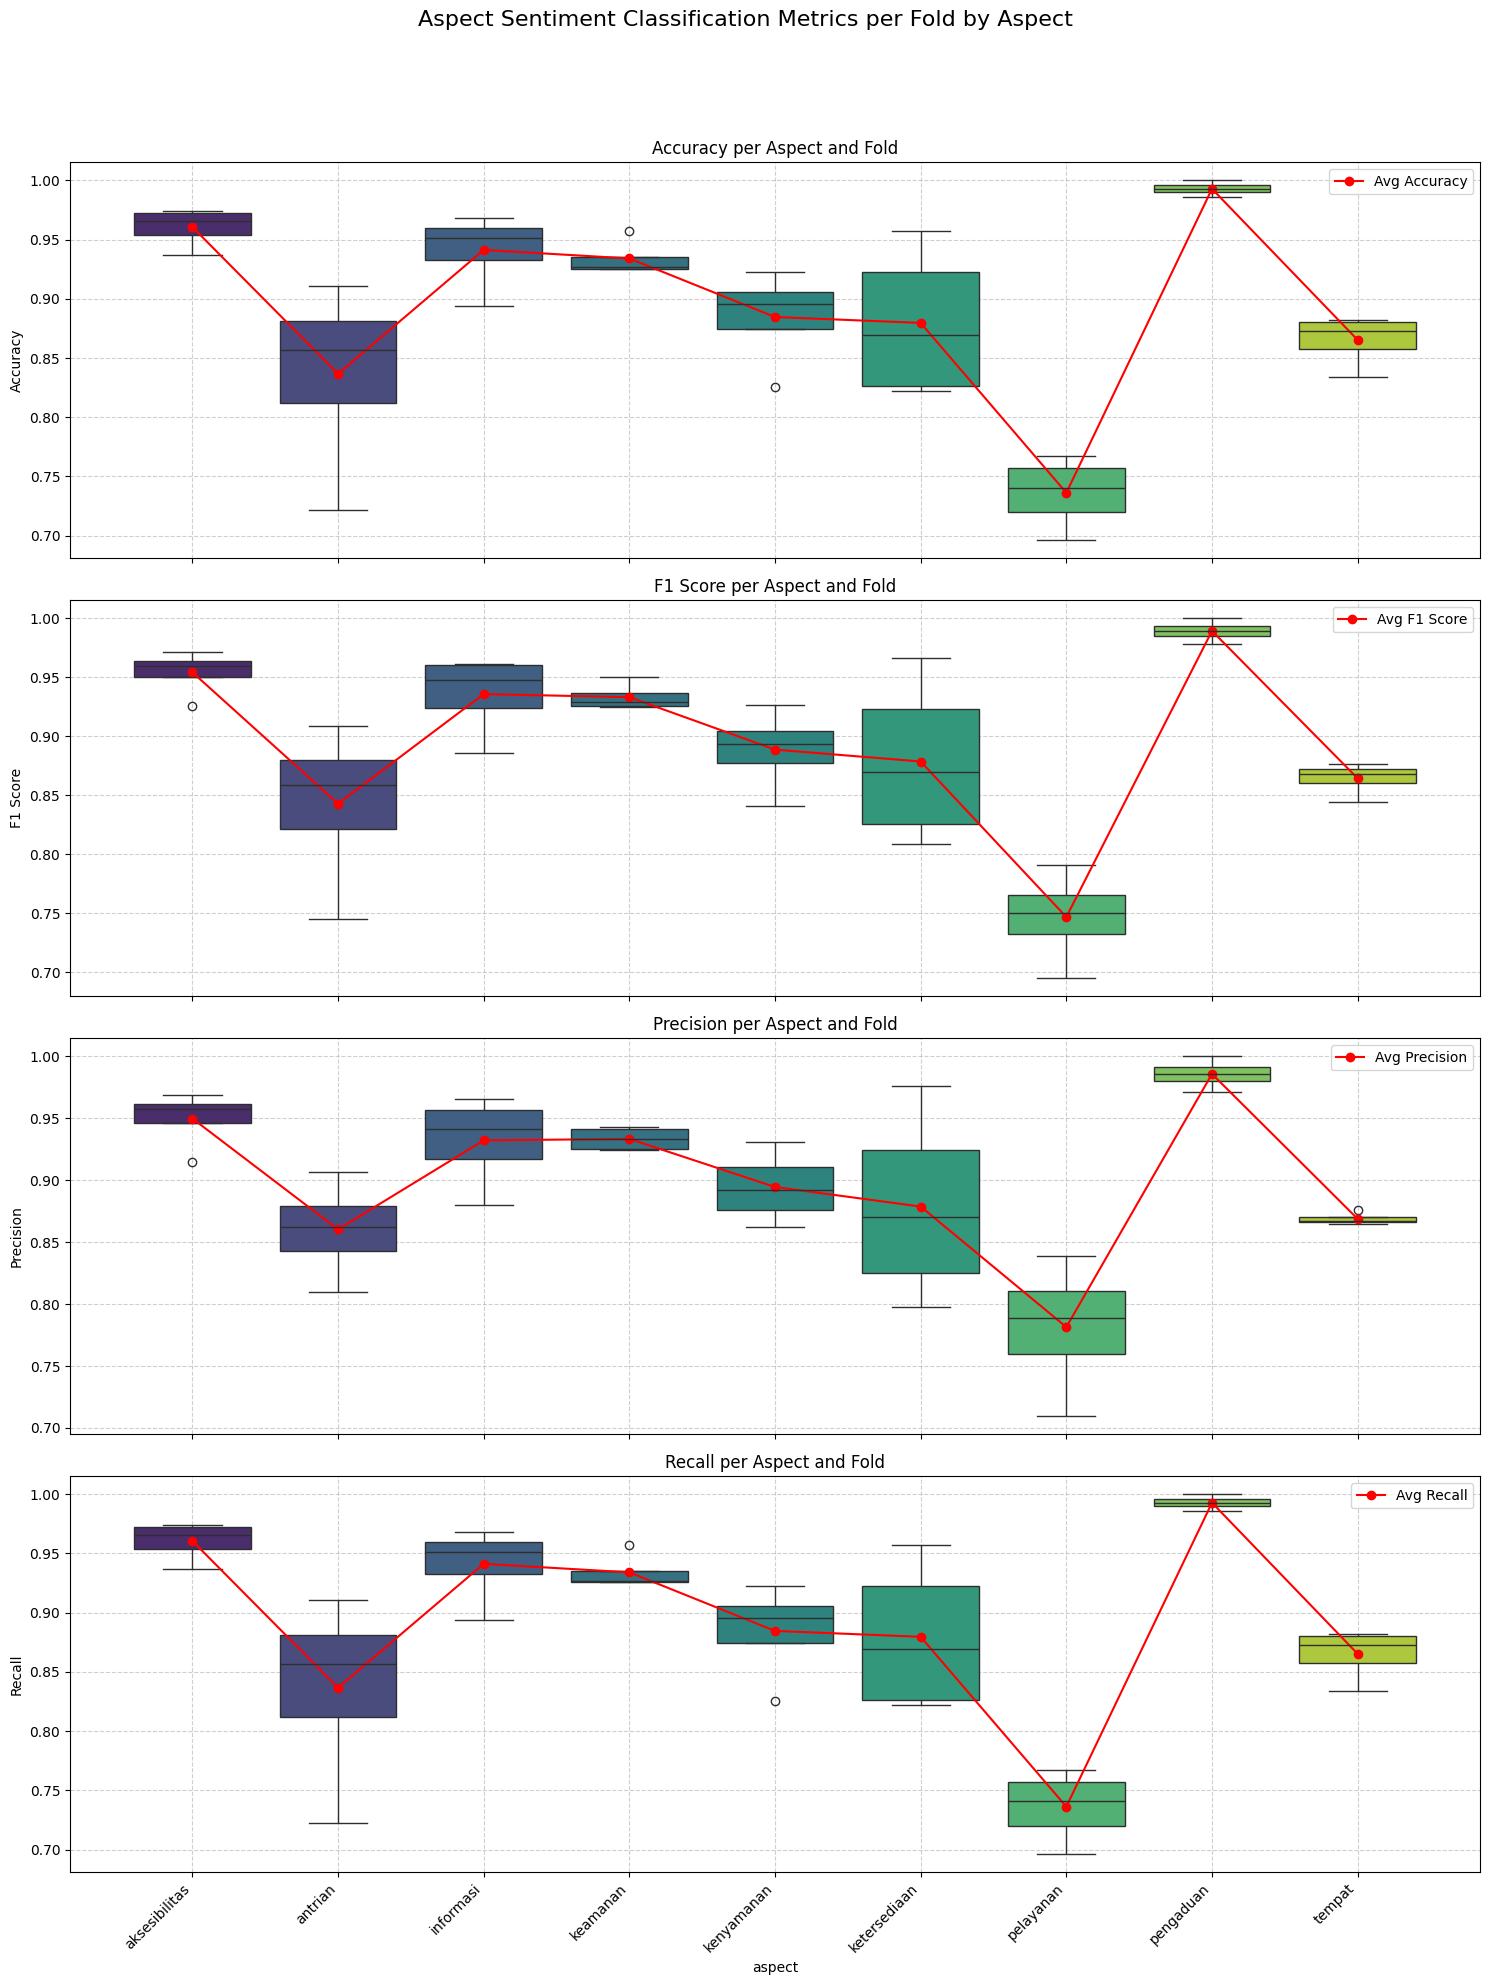


Generating Rating Metrics Plots...
Rating metrics plot saved to /content/drive/MyDrive/Semester VIII/Tugas Akhir/Results/rating_metrics_plot.png


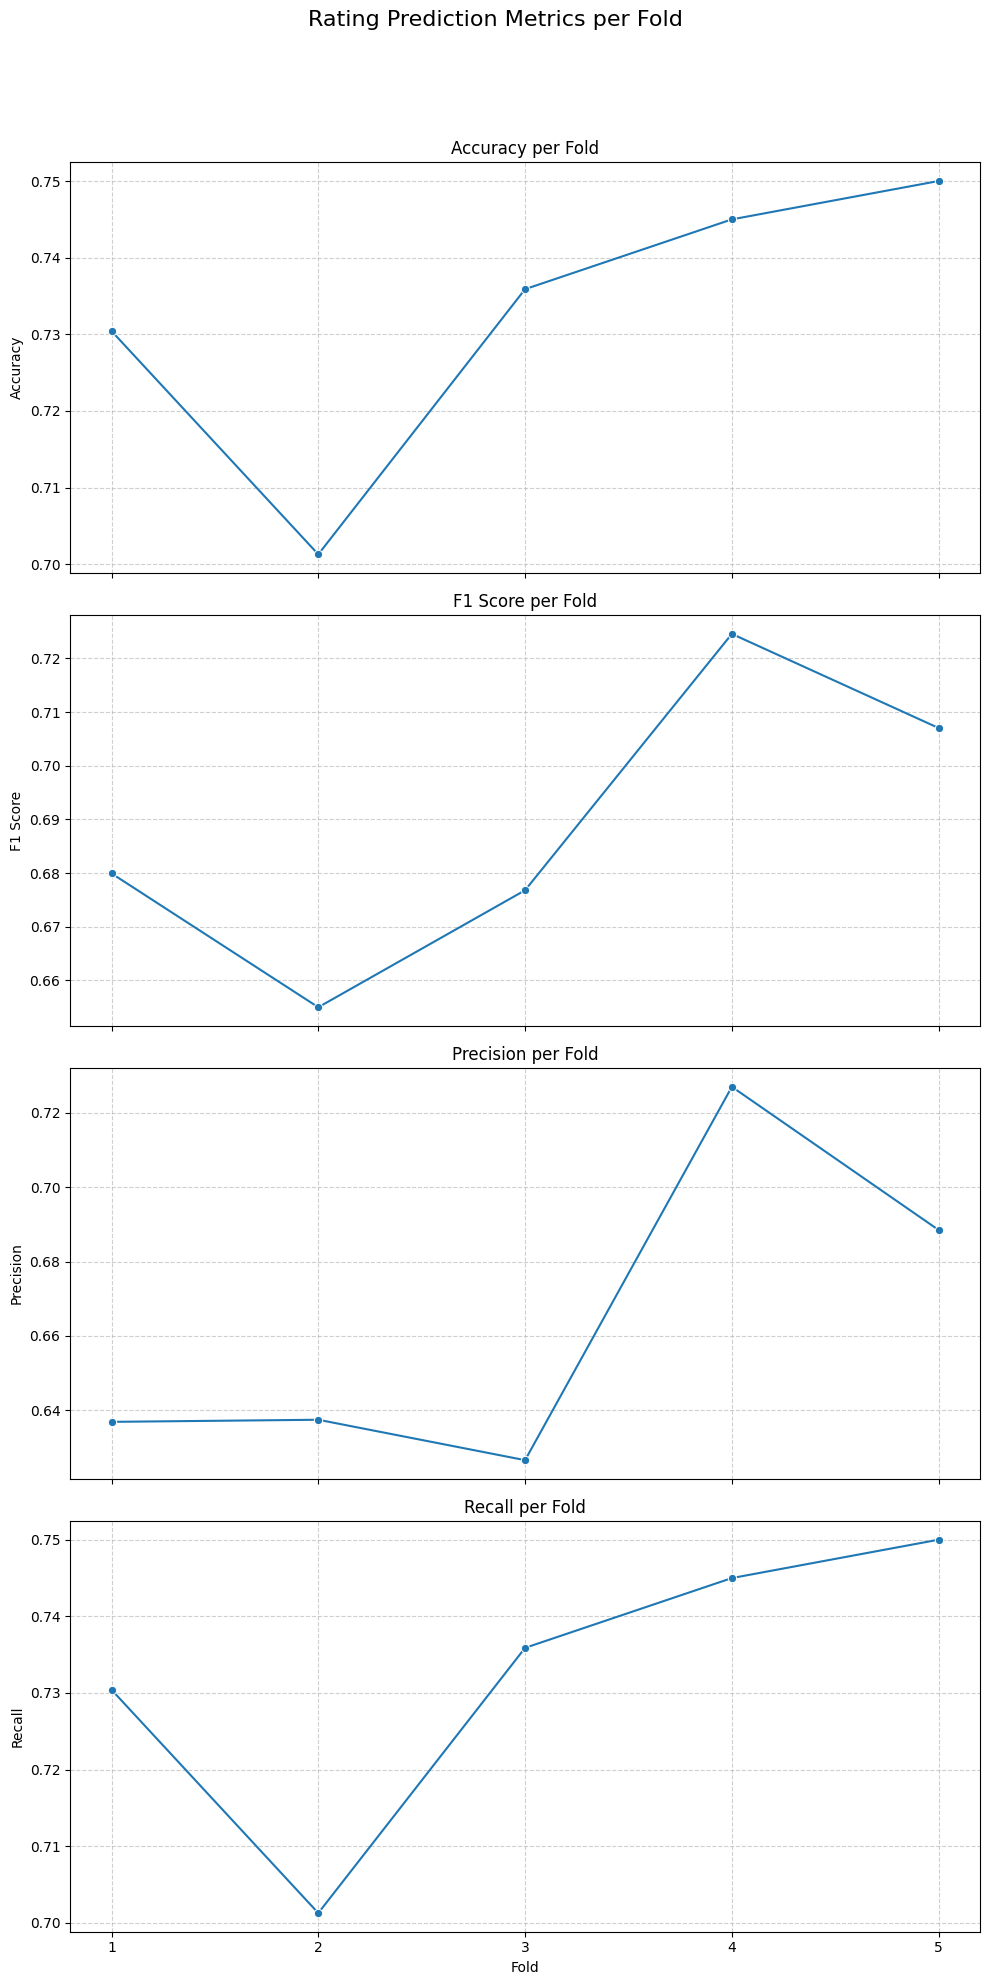


Displaying Top 30 Locations with Worst Aspect Sentiment (Year: All)...
Analyzing using predicted aspect columns: ['ketersediaan_predicted', 'pelayanan_predicted', 'tempat_predicted', 'kenyamanan_predicted', 'antrian_predicted', 'informasi_predicted', 'keamanan_predicted', 'pengaduan_predicted', 'aksesibilitas_predicted']

Top 30 Locations with Lowest Average Aspect Sentiment (using columns: ['ketersediaan_predicted', 'pelayanan_predicted', 'tempat_predicted', 'kenyamanan_predicted', 'antrian_predicted', 'informasi_predicted', 'keamanan_predicted', 'pengaduan_predicted', 'aksesibilitas_predicted']):


,ketersediaan_predicted,pelayanan_predicted,tempat_predicted,kenyamanan_predicted,antrian_predicted,informasi_predicted,keamanan_predicted,pengaduan_predicted,aksesibilitas_predicted,Average_Sentiment
Location,,,,,,,,,,
Bank BNI Jl.Garuda,1.01,0.94,1.09,1.09,0.83,0.97,0.99,0.98,1.05,0.99
Bank Jateng KCP Gading,0.96,1.11,1.00,1.00,0.89,1.00,1.00,1.00,1.00,1.00
Bank Jateng KCP Delanggu,1.04,0.92,1.12,1.08,0.79,1.00,1.00,1.00,1.08,1.00
Bank BNI Solo Baru,1.03,0.99,1.10,1.10,0.85,0.96,1.00,1.00,1.03,1.00
Bank Jateng KCP Nusukan Surakarta,1.02,1.10,1.06,1.06,0.87,1.00,1.00,1.00,1.02,1.01
Bank Jateng KCP Solo Baru,1.00,1.03,1.06,1.03,0.94,1.00,1.03,1.00,1.03,1.01
Bank Jateng Karanganyar,1.06,1.12,1.06,1.04,0.82,1.00,1.01,1.00,1.01,1.01
Bank BNI Jaten,1.00,1.02,1.09,1.09,0.94,0.99,1.00,1.00,1.01,1.02
Bank Jateng KC Klaten,1.11,1.03,1.06,1.09,0.89,0.98,1.02,1.00,1.00,1.02



Worst Aspect for Each of the Top 30 Locations:


,Location,Worst_Aspect,Avg_Sentiment_Score,Approx_Sentiment
0,Bank BNI Jl.Garuda,antrian,0.83,Not Mentioned/Netral
1,Bank Jateng KCP Gading,antrian,0.89,Not Mentioned/Netral
2,Bank Jateng KCP Delanggu,antrian,0.79,Not Mentioned/Netral
3,Bank BNI Solo Baru,antrian,0.85,Not Mentioned/Netral
4,Bank Jateng KCP Nusukan Surakarta,antrian,0.87,Not Mentioned/Netral
5,Bank Jateng KCP Solo Baru,antrian,0.94,Not Mentioned/Netral
6,Bank Jateng Karanganyar,antrian,0.82,Not Mentioned/Netral
7,Bank BNI Jaten,antrian,0.94,Not Mentioned/Netral
8,Bank Jateng KC Klaten,antrian,0.89,Not Mentioned/Netral
9,Bank BNI Colomadu,antrian,0.96,Not Mentioned/Netral


--------------------------------------------------
Visualization complete.

Bank Review Analysis Pipeline Finished.
Combined results saved to: /content/drive/MyDrive/Semester VIII/Tugas Akhir/Results/bank_review_analysis_results.csv
Metrics saved to directory: /content/drive/MyDrive/Semester VIII/Tugas Akhir/Metrics/

--- Main Execution Finished ---


In [ ]:
config = Config()
print("Configuration loaded.")

analyzer = BankReviewAnalyzer(config)
print("BankReviewAnalyzer initialized.")

analyzer.run_pipeline()

print("\n--- Main Execution Finished ---")

In [ ]:

# ======================================================================
#      ANALISIS & EVALUASI METRIK DARI FILE CSV
# ======================================================================

# Definisikan path ke direktori metrik Anda
metrics_output_dir = '/content/drive/MyDrive/Semester VIII/Hasil BiLSTM/Metrics_final/'

# Definisikan path lengkap ke file CSV
aspect_metrics_path = os.path.join(metrics_output_dir, 'aspect_fold_metrics.csv')
rating_metrics_path = os.path.join(metrics_output_dir, 'rating_fold_metrics.csv')

# Atur opsi tampilan pandas agar lebih rapi
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("======================================================")
print("     HASIL EVALUASI METRIK MODEL (dari File CSV)      ")
print("======================================================")

# --- 1. Evaluasi Model Aspek ---
print("\\n--- 📊 Model Klasifikasi Sentimen Aspek ---\\n")
try:
    # Baca file metrik aspek
    aspect_metrics_df = pd.read_csv(aspect_metrics_path)
    print(f"Berhasil memuat data dari: {aspect_metrics_path}")

    # --- PENAMBAHAN: Hitung rata-rata keseluruhan untuk semua aspek ---
    print("\\n✨ Rata-rata KESELURUHAN Model Aspek (di semua fold dan aspek)")
    overall_avg = aspect_metrics_df.mean(numeric_only=True)
    overall_std = aspect_metrics_df.std(numeric_only=True)

    overall_summary_df = pd.DataFrame({'Rata-rata': overall_avg, 'Std. Dev.': overall_std})
    if 'fold' in overall_summary_df.index:
        overall_summary_df = overall_summary_df.drop(index='fold')

    print(overall_summary_df.round(4).to_string())
    print("======================================================")
    # ----------------------------------------------------------------

    print("\\nAnalisis Detail per Aspek:")
    # Kelompokkan berdasarkan nama aspek untuk detail per aspek
    for aspect_name, group_df in aspect_metrics_df.groupby('aspect'):
        print(f"🔹 Aspek: {aspect_name.capitalize()}")

        print("  Metrik per Fold:")
        print(group_df.drop(columns=['aspect']).round(4).to_string(index=False))

        avg_metrics = group_df.mean(numeric_only=True)
        std_metrics = group_df.std(numeric_only=True)

        print("\\n  Rata-rata & Standar Deviasi (per Aspek):")
        summary_df = pd.DataFrame({'Rata-rata': avg_metrics, 'Std. Dev.': std_metrics})
        if 'fold' in summary_df.index:
            summary_df = summary_df.drop(index='fold')

        print(summary_df.round(4).to_string())
        print("-" * 55)

except FileNotFoundError:
    print(f"File tidak ditemukan: {aspect_metrics_path}")
except Exception as e:
    print(f"Terjadi error saat memproses metrik aspek: {e}")

# --- 2. Evaluasi Model Rating ---
print("\\n\n--- ⭐️ Model Prediksi Rating ---\\n")
try:
    rating_metrics_df = pd.read_csv(rating_metrics_path)
    print(f"Berhasil memuat data dari: {rating_metrics_path}")

    print("  Metrik per Fold:")
    print(rating_metrics_df.round(4).to_string(index=False))

    avg_metrics = rating_metrics_df.mean(numeric_only=True)
    std_metrics = rating_metrics_df.std(numeric_only=True)

    print("\\n  Rata-rata & Standar Deviasi:")
    summary_df = pd.DataFrame({'Rata-rata': avg_metrics, 'Std. Dev.': std_metrics})
    if 'fold' in summary_df.index:
        summary_df = summary_df.drop(index='fold')

    if 'mae' in summary_df.index:
         print("  (Metrik Regresi - lebih rendah lebih baik)")
    else:
         print("  (Metrik Klasifikasi - lebih tinggi lebih baik)")

    print(summary_df.round(4).to_string())
    print("-" * 55)

except FileNotFoundError:
    print(f"File tidak ditemukan: {rating_metrics_path}")
except Exception as e:
    print(f"Terjadi error saat memproses metrik rating: {e}")

print("\n======================================================")

     HASIL EVALUASI METRIK MODEL (dari File CSV)      
\n--- 📊 Model Klasifikasi Sentimen Aspek ---\n
Berhasil memuat data dari: /content/drive/MyDrive/Semester VIII/Hasil BiLSTM/Metrics_final/aspect_fold_metrics.csv
\n✨ Rata-rata KESELURUHAN Model Aspek (di semua fold dan aspek)
           Rata-rata  Std. Dev.
accuracy      0.8923     0.0822
f1_score      0.8926     0.0776
precision     0.8983     0.0672
recall        0.8923     0.0822
\nAnalisis Detail per Aspek:
🔹 Aspek: Aksesibilitas
  Metrik per Fold:
 fold  accuracy  f1_score  precision  recall
    1    0.9370    0.9259     0.9150  0.9370
    2    0.9599    0.9579     0.9561  0.9599
    3    0.9713    0.9619     0.9590  0.9713
    4    0.9741    0.9713     0.9688  0.9741
\n  Rata-rata & Standar Deviasi (per Aspek):
           Rata-rata  Std. Dev.
accuracy      0.9606     0.0169
f1_score      0.9542     0.0197
precision     0.9498     0.0238
recall        0.9606     0.0169
-------------------------------------------------------
🔹 

In [ ]:
import pandas as pd
import numpy as np
import os
import re
from datetime import datetime
from dateutil.relativedelta import relativedelta
import itertools

# ======================================================================
#         FUNGSI KONVERSI TANGGAL RELATIF KE FORMAT dd/mm/yyyy
# ======================================================================

def convert_to_exact_date(date_str):
    """
    Mengubah teks waktu relatif seperti '2 tahun lalu' menjadi format dd/mm/yyyy.
    """
    if not isinstance(date_str, str):
        return pd.NaT

    date_str = date_str.lower().strip()
    now = datetime.now()

    try:
        dt = pd.to_datetime(date_str, dayfirst=True, errors='raise')
        return dt.strftime('%d/%m/%Y')
    except Exception:
        pass

    match = re.search(r'(\d+)', date_str)
    amount = int(match.group(1)) if match else 1

    if 'tahun' in date_str or 'year' in date_str:
        result_date = now - relativedelta(years=amount)
    elif 'bulan' in date_str or 'month' in date_str:
        result_date = now - relativedelta(months=amount)
    elif 'minggu' in date_str or 'week' in date_str:
        result_date = now - relativedelta(weeks=amount)
    elif 'hari' in date_str or 'day' in date_str:
        result_date = now - relativedelta(days=amount)
    else:
        return pd.NaT

    return result_date.strftime('%d/%m/%Y')

# ======================================================================
#      ANALISIS ASPEK TERBURUK PER TAHUN & LOKASI BANK
# ======================================================================

results_csv_path = '/content/drive/MyDrive/Semester VIII/Hasil BiLSTM/Results_final/bank_review_analysis_results.csv'

print("======================================================")
print("     ANALISIS ASPEK DENGAN KELUHAN TERBANYAK      ")
print("======================================================")

try:
    print(f"Membaca data dari: {results_csv_path}")
    results_df = pd.read_csv(results_csv_path)

    if 'Time' in results_df.columns:
        print("Mengonversi kolom 'Time' ke format dd/mm/yyyy...")
        # 1. Konversi dengan fungsi khusus ke string tanggal
        results_df['Time_preprocessed'] = results_df['Time'].apply(convert_to_exact_date)
        results_df['Time_preprocessed'] = pd.to_datetime(results_df['Time_preprocessed'], dayfirst=True, errors='coerce')
        results_df = results_df.dropna(subset=['Time_preprocessed'])
        results_df.to_csv('/content/drive/MyDrive/Semester VIII/Hasil BiLSTM/Results_final/bank_review_analysis_results.csv', index=False)
        results_df['year'] = results_df['Time_preprocessed'].dt.year

        print("Konversi sukses. Kolom 'year' berhasil dibuat.")
    else:
        raise ValueError("Kolom 'Time' tidak ditemukan di file CSV.")

    # Tahun yang akan dianalisis
    start_year = 2020
    end_year = 2025
    years_to_analyze = range(start_year, end_year + 1)

    all_locations = sorted(results_df['Location'].unique())
    all_combinations = list(itertools.product(years_to_analyze, all_locations))

    aspect_columns = [col.replace('_predicted', '') for col in results_df.columns if col.endswith('_predicted') and not col.startswith('rating')]

    current_year = None
    print("\n--- Hasil Analisis Temporal ---")

    for year, location in all_combinations:
        if year != current_year:
            print(f"\n╔════════════════════════════════════════════╗")
            print(f"║                   TAHUN {int(year)}                  ║")
            print(f"╚════════════════════════════════════════════╝")
            current_year = year

        group_df = results_df[(results_df['year'] == year) & (results_df['Location'] == location)]
        print(f"\n📍 LOKASI: {location}")

        if group_df.empty:
            print("   ⚪ Tidak ada data ulasan negatif yang ditemukan untuk periode ini.")
            continue

        print(f"   (Total {len(group_df)} ulasan ditemukan)")

        predicted_aspect_columns = [f"{col}_predicted" for col in aspect_columns]
        negative_counts = group_df[predicted_aspect_columns].apply(lambda col: (col == 'negatif').sum())
        negative_counts.index = aspect_columns

        max_negative_count = negative_counts.max()

        if max_negative_count == 0:
            print("   ✅ Tidak ada keluhan negatif yang signifikan ditemukan.")
            continue

        worst_aspects = negative_counts[negative_counts == max_negative_count].index.tolist()

        print(f"   📉 Aspek dengan Keluhan Terbanyak:")
        for aspect in worst_aspects:
            percentage = (max_negative_count / len(group_df)) * 100
            print(f"      - Aspek: '{aspect.capitalize()}'")
            print(f"        > Jumlah Keluhan Negatif: {int(max_negative_count)} keluhan")
            print(f"        > Persentase dari Total: {percentage:.1f}% dari ulasan di lokasi ini")

except FileNotFoundError:
    print(f"\nERROR: File tidak ditemukan di path berikut: {results_csv_path}")
except Exception as e:
    print(f"\nTerjadi error saat memproses file: {e}")

print("\n======================================================")


     ANALISIS ASPEK DENGAN KELUHAN TERBANYAK      
Membaca data dari: /content/drive/MyDrive/Semester VIII/Hasil BiLSTM/Results_final/bank_review_analysis_results.csv
Mengonversi kolom 'Time' ke format dd/mm/yyyy...
Konversi sukses. Kolom 'year' berhasil dibuat.

--- Hasil Analisis Temporal ---

╔════════════════════════════════════════════╗
║                   TAHUN 2020                  ║
╚════════════════════════════════════════════╝

📍 LOKASI: Bank BNI Cabang Sebelas Maret
   (Total 7 ulasan ditemukan)
   📉 Aspek dengan Keluhan Terbanyak:
      - Aspek: 'Ketersediaan'
        > Jumlah Keluhan Negatif: 1 keluhan
        > Persentase dari Total: 14.3% dari ulasan di lokasi ini
      - Aspek: 'Pelayanan'
        > Jumlah Keluhan Negatif: 1 keluhan
        > Persentase dari Total: 14.3% dari ulasan di lokasi ini
      - Aspek: 'Tempat'
        > Jumlah Keluhan Negatif: 1 keluhan
        > Persentase dari Total: 14.3% dari ulasan di lokasi ini
      - Aspek: 'Kenyamanan'
        > Jumla